# Load Libraries

In [25]:

%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
from pathlib import Path
import importlib.util
from joblib import Parallel, delayed
import os

def _find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in (current, *current.parents):
        if (candidate / "functions").is_dir() and (candidate / "pyspedas").is_dir():
            return candidate
    raise RuntimeError("Could not locate MHDTurbPy root (missing functions/ and pyspedas/).")


root_dir = _find_repo_root(Path.cwd())
path_setup_file = root_dir / "functions" / "path_setup.py"
spec = importlib.util.spec_from_file_location("mhdturbpy_path_setup", path_setup_file)
if spec is None or spec.loader is None:
    raise RuntimeError(f"Could not load path setup from {path_setup_file}")
path_setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(path_setup)

root_dir = path_setup.ensure_project_paths(
    start=Path.cwd(),
    include_downloading_helpers=True,
    include_anisotropy_toolbox=True,
    include_sc_pos=True,
)


from functions import download_data as download

from functions import  calc_diagnostics as calc
from functions import  TurbPy as turb
from functions import general_functions as func
from functions import  Figures as figs
from functions import  interactive_figs

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Doawnload data

In [2]:
"""
mre_run_solo.py

Minimal-but-complete MRE to run the SOLO pipeline.

RUN FROM REPO ROOT (the directory that contains: pyspedas/, functions/, download_data.py)
"""







# ---------------------------------------------------------------------
# CDFlib path (needed for SOLO distance download via CDAS)
# ---------------------------------------------------------------------
cdf_lib_path = "/Applications/cdf/cdf/lib"


# ---------------------------------------------------------------------
# Credentials (None is fine for SOLO in most cases)
# ---------------------------------------------------------------------
credentials = None


# How many cores to use
n_jobs     = 1

# ---------------------------------------------------------------------
# Settings (organized by topic, then flattened into one dict)
# ---------------------------------------------------------------------
Paths = {
    
        "Data_path"         : Path(root_dir).joinpath('data'),
        "save_destination"  :  Path(root_dir).joinpath('examples').joinpath('noise_removal'),
        #"SOLO_dist_path"    : "/Users/turbulator/work/turb_amplitudes/SOLO/solo_dist.pkl",
}

Mission = { 
    "sc"             : "SOLO",
    "in_rtn"         : True,
    "use_local_data" : False,

    "SOLO_use_merged_MAG" : True,   # set False to use SPEDAS L2 MAG
    "SOLO_merged_fs"      : 256,         # 256 or 4096
}

# ---- Unified MAG noise removal (works for SOLO merged MAG and PSP SCAM)
# This is the preferred key; legacy Mag_SCAM_PSP["noise_flag"] still works.
MAG_NOISE = {
    "Mag_SCM": {
        "noise_flag": False,
        "noise_removal": {
            "freq_min": 8.0,

            "stft_nperseg": 2048,
            "stft_overlap": 0.5,

            "percentile_q": 99.5,
            "kernel": 301,
            "thresh_db": 3.0,
            "merge_hz": 0.20,
            "max_lines": 2000,

            "track_half_width_hz": 5.0,
            "remove_half_width_hz": 1.5,
            "atten_db": 100.0,

            "fallback_top_k": 120,
            "whiten_exp": 0.0,
        },
    }
}


Intervals = {
    # "start_date": "2025-01-10 00:00",
    # "end_date": "2025-01-10 06:00",



    #2024-10-01_01-00-00_2024-10-01_03-00-00_sc_0\\final.pkl'
    "start_date": "2024-10-01 01:00",
    "end_date": "2024-10-01 03:00",
    
    "multiple_intervals": False,   # False -> single interval, True -> use Step/duration below
    "duration": "30d",
    "Step": "30d",
    "addit_time_around": 1,        # hours padding in LoadTimeSeriesSOLO
}

Sampling = {
    "part_resol": 1,
    "MAG_resol": 1,
    "upsample_low_freq_ts": False,
}

QualityControl = {
    "overwrite_files"   :  1,
    "must_have_qtn": False,
    "Max_par_missing": 30,
    "gap_time_threshold": 5,
    "use_hampel": False,
    "hampel_params": {"w": 200, "std": 3},
}

Output = {
    
    "save_all": True,
    "cut_in_small_windows": {
        "flag": False,
        "njobs": 1,
        "Step": "5s",
        "duration": "30s",
    },
}

Diagnostics = {
    "estimate_derived_param": True,
    "rol_window": "60min",

    "PSDs": {"flag": False},
    "struc_funcs": {"flag": False},

    "npt_struc_funcs": {
        "flag": False,
        "five_points_sfunc": True,
        "return_Bmod": True,
        "dt_step": 0.25,
        "est_sfuncs": False,
        "max_qorder": 8,
    },

    "estimate_psd_b": True,
    "estimate_psd_v": True,
    "est_PSD_components": True,
    "smooth_psd": False,
}

Gaps = {
    "Big_Gaps": {
        "E_big_gaps": 10,
        "SC_pot_big_gaps": 10,
        "Mag_big_gaps": 500,
        "Par_big_gaps": 500,
        "QTN_big_gaps": 10,
    }
}










# ---- final settings dict (what pipeline consumes)
settings = {
    **Paths,
    **Mission,
    **Intervals,
    **Sampling,
    **QualityControl,
    **Output,
    **Diagnostics,

    **MAG_NOISE,
    "Big_Gaps": Gaps["Big_Gaps"],
}


# ---------------------------------------------------------------------
# What variables to download (None -> defaults inside SOLO.py)
# ---------------------------------------------------------------------
vars_2_downnload = {
    "mag": None,
    "swa": None,
    "rpw": None,
    "ephem": None,
}


# ---------------------------------------------------------------------
# Interval generation
# ---------------------------------------------------------------------
generated_interval_list = download.generate_intervals(
    settings["start_date"],
    settings["end_date"],
    settings["multiple_intervals"],
    data_path=settings["Data_path"],
    settings=settings,
)


# ---------------------------------------------------------------------
# Run download for each interval
# ---------------------------------------------------------------------
os.chdir(settings["Data_path"])

save_path = Path(settings["save_destination"]).joinpath(settings["sc"])
save_path.mkdir(parents=True, exist_ok=True)

Parallel(n_jobs=n_jobs)(
    delayed(download.download_files)(
        jj,
        generated_interval_list,
        settings,
        vars_2_downnload,
        cdf_lib_path,
        credentials,
        save_path,
    )
    for jj in range(len(generated_interval_list))
)


18-Feb-26 11:56:40: Generating only one interval based on the provided start and end times.
18-Feb-26 11:56:40: Start Time: 2024-10-01 01:00:00
End Time: 2024-10-01 03:00:0000

18-Feb-26 11:56:40: Considering a single interval spanning: 2024-10-01 01:00:00 to 2024-10-01 03:00:00
Overwriting folder C:\Users\nokni\work\MHDTurbPy\examples\noise_removal\SOLO\2024-10-01_01-00-00_2024-10-01_03-00-00_sc_0
18-Feb-26 11:56:41: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/solar-orbiter/rpw/science/l3/bia-density-10-seconds/2024/
2: Remote index not found: https://spdf.gsfc.nasa.gov/pub/data/solar-orbiter/rpw/science/l3/bia-density-10-seconds/2024/4/

18-Feb-26 11:56:44: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/solar-orbiter/swa/science/l2/pas-grnd-mom/2024/
File is current: solar_orbiter_data/swa/science/l2/pas-grnd-mom/2024/solo_l2_swa-pas-grnd-mom_20241001_v02.cdf
18-Feb-26 11:56:46: C:\Users\nokni\anaconda3\envs\numba\lib\site-packages\drms\version.py:25:

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

18-Feb-26 11:57:00: SOAR merged dataset loaded successfully.
18-Feb-26 11:57:00: MAG_source=SOAR_MERGED_SCM | SCM_merged_loaded=True | SOAR_product=multi-mag-rpw-scm-merged-rtn-256
6: C:\Users\nokni\work\MHDTurbPy\functions\calc_diagnostics.py:474: RuntimeWarning: Mean of empty slice
  r_psp = np.nanmean(func.use_dates_return_elements_of_df_inbetween(



Index(['Br', 'Bt', 'Bn', 'np', 'Vr', 'Vt', 'Vn', 'sc_vel_r', 'sc_vel_t',
       'sc_vel_n', 'Tp', 'Vth', 'np_qtn', 'ne_qtn', 'Dist_au', 'Br_mean',
       'Bt_mean', 'Bn_mean', 'Vr_mean', 'Vt_mean', 'Vn_mean', 'np_mean'],
      dtype='object')


18-Feb-26 11:57:14: C:\Users\nokni\anaconda3\envs\numba\lib\asyncio\base_events.py:686: ResourceWarning: unclosed event loop <_WindowsSelectorEventLoop running=False closed=False debug=False>
  _warn(f"unclosed event loop {self!r}", ResourceWarning, source=self)



0 out of 1 finished


[None]

In [ ]:
,

In [3]:
import pandas as pd

#  User defined parameters
sc          = 'SOLO'
which_int   =1
load_path   = Path(root_dir).joinpath('examples').joinpath('noise_removal').joinpath(sc)


# Locate the downloaded files
finnames      = func.load_files(load_path, 'final.pkl')
gennames      = func.load_files(load_path, 'general.pkl')
signames      = func.load_files(load_path, 'sig_c_sig_r.pkl')
maggaps       = func.load_files(load_path, 'mag_gaps.pkl')
qtngaps       = func.load_files(load_path, 'qtn_gaps.pkl')
pargaps       = func.load_files(load_path, 'par_gaps.pkl')
sc_pot        = func.load_files(load_path, 'sc_pot_gaps.pkl')


#Load the filed
fin         = pd.read_pickle(finnames[which_int])
gen         = pd.read_pickle(gennames[which_int])
sig         = pd.read_pickle(signames[which_int])
mag_gaps    = pd.read_pickle(maggaps[which_int])
qtn_gaps    = pd.read_pickle(qtngaps[which_int])
par_gaps    = pd.read_pickle(pargaps[which_int])
sc_pot_gaps = pd.read_pickle(sc_pot[which_int])

finnames[which_int]

C:\Users\nokni\work\MHDTurbPy\examples\noise_removal\SOLO\*\final.pkl
C:\Users\nokni\work\MHDTurbPy\examples\noise_removal\SOLO\*\general.pkl
C:\Users\nokni\work\MHDTurbPy\examples\noise_removal\SOLO\*\sig_c_sig_r.pkl
C:\Users\nokni\work\MHDTurbPy\examples\noise_removal\SOLO\*\mag_gaps.pkl
C:\Users\nokni\work\MHDTurbPy\examples\noise_removal\SOLO\*\qtn_gaps.pkl
C:\Users\nokni\work\MHDTurbPy\examples\noise_removal\SOLO\*\par_gaps.pkl
C:\Users\nokni\work\MHDTurbPy\examples\noise_removal\SOLO\*\sc_pot_gaps.pkl


'C:\\Users\\nokni\\work\\MHDTurbPy\\examples\\noise_removal\\SOLO\\2024-10-01_01-00-00_2024-10-01_03-00-00_sc_0\\final.pkl'

In [43]:
y5

0.055069737

18-Feb-26 11:08:16: C:\Users\nokni\work\MHDTurbPy\functions\TurbPy.py:1448: DeprecationWarning: invalid escape sequence \e
  

18-Feb-26 11:08:17: C:\Users\nokni\work\MHDTurbPy\functions\TurbPy.py:218: RuntimeWarning: divide by zero encountered in divide
  return_Bmod       = False,

invalid value encountered in dividee
  return_Bmod       = False,


  return_Bmod       = False,



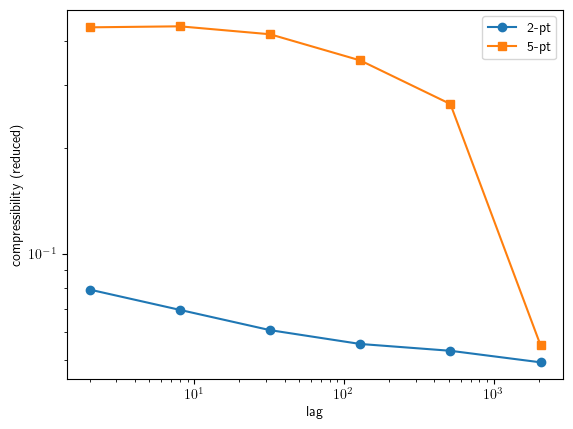

In [44]:
import numpy as np
import matplotlib.pyplot as plt

B = fin["Mag"]["B_resampled"]

lags = 2 ** np.arange(1, 12, 2)   # 1D: [2, 8, 32, 128, 512, 2048] if stop=12

cb2_list = []
cb5_list = []

for lag in lags:
    y2 = turb.parallel_compress(int(lag), B, five_points_sfunc=False)
    y5 = turb.parallel_compress(int(lag), B, five_points_sfunc=True)

    # If y2/y5 are arrays (per-time), reduce to a scalar for plotting vs lag
    y2s = np.nanmean(y2) if np.ndim(y2) > 0 else float(y2)
    y5s = np.nanmean(y5) if np.ndim(y5) > 0 else float(y5)

    cb2_list.append(y2s)
    cb5_list.append(y5s)

cb2 = np.array(cb2_list, dtype=float)
cb5 = np.array(cb5_list, dtype=float)

plt.loglog(lags, cb2, marker="o", label="2-pt")
plt.loglog(lags, cb5, marker="s", label="5-pt")
plt.xlabel("lag")
plt.ylabel("compressibility (reduced)")
plt.legend()
plt.show()


array([      2,       8,      32,     128,     512,    2048,    8192,
         32768,  131072,  524288, 2097152, 8388608], dtype=int32)

In [11]:
parallel_compress

,compress
datetime,
2024-10-01 01:00:10.002,0.000993
2024-10-01 01:00:10.005,0.001078
2024-10-01 01:00:10.008,0.001257
2024-10-01 01:00:10.011,0.001360
2024-10-01 01:00:10.014,0.001632
...,...
2024-10-01 02:59:46.986,NaN
2024-10-01 02:59:46.989,NaN
2024-10-01 02:59:46.992,NaN


In [53]:
B          = fin["Mag"]["B_resampled"]
max_qorder = 8
scales     = 2 ** np.arange(1, 16, 1)   # 1D: [2, 8, 32, 128, 512, 2048] if stop=12


pt_5 = turb.structure_functions_parallel(
    B,
    scales,
    max_qorder,
    five_points_sfunc=True,
    keep_sdk=True,
    return_components=True,
    return_Bmod=True,
    return_compress=True,
    return_flucts=False,
    n_jobs=-1,
    return_all=False,
)

In [54]:
pt_2 = turb.structure_functions_parallel(
    B,
    scales,
    max_qorder,
    five_points_sfunc=False,
    keep_sdk=True,
    return_components=True,
    return_Bmod=True,
    return_compress=True,
    return_flucts=False,
    n_jobs=-1,
    return_all=False,
)

In [58]:
pt_2.keys()

dict_keys(['scales', 'qorders', 'SF_trace', 'SF_components', 'SF_Bmod', 'SDK', 'compress', 'counts_Bmod', 'dB', 'dBmod', 'meta'])

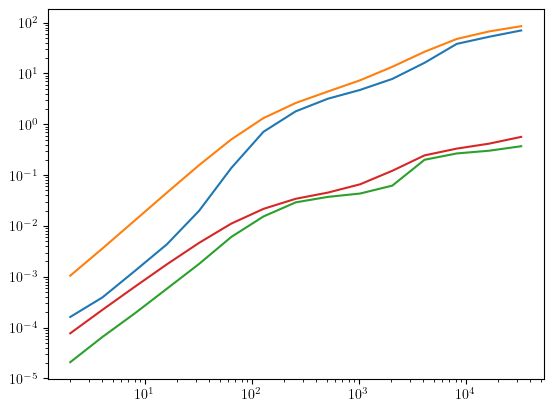

In [59]:
plt.loglog(pt_5['scales'], pt_5['SF_trace'].T[1])
plt.loglog(pt_2['scales'], pt_2['SF_trace'].T[1])


plt.loglog(pt_5['scales'], pt_5['SF_Bmod'].T[1])
plt.loglog(pt_2['scales'], pt_2['SF_Bmod'].T[1])

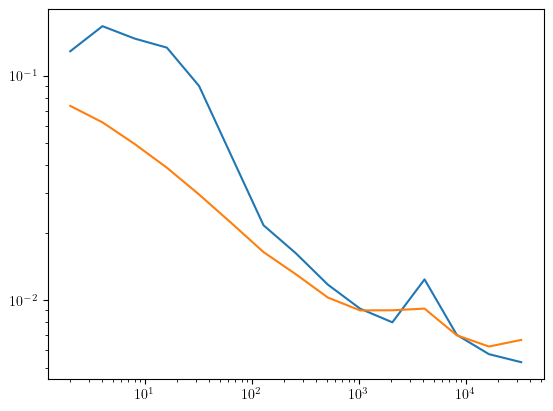

In [62]:
N = 1

plt.loglog(pt_5['scales'], pt_5['SF_Bmod'].T[N]/pt_5['SF_trace'].T[N])
plt.loglog(pt_2['scales'], pt_2['SF_Bmod'].T[N]/ pt_2['SF_trace'].T[N])


# plt.loglog(pt_5['scales'], pt_5['SF_Bmod'].T[1])
# plt.loglog(pt_2['scales'], pt_2['SF_Bmod'].T[1])

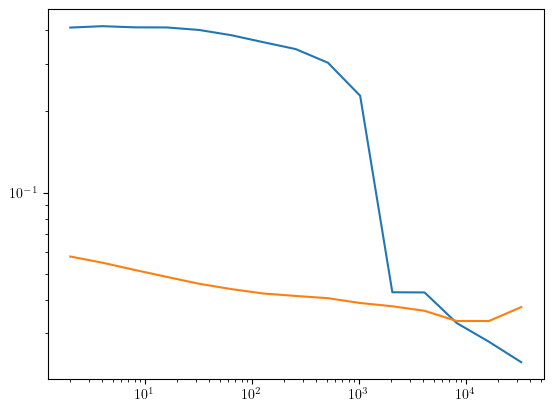

In [56]:
plt.loglog(pt_5['scales'], pt_5['compress'])
plt.loglog(pt_2['scales'], pt_2['compress'])

In [84]:
func_params = {'dt_step': 2, 'max_qorder' : 8, 'five_points_sfunc': True, 'return_Bmod': True}


sf_5 = turb.est_5_pt_sfuncs(B,
                    func.find_cadence(B),
                    func_params = func_params)

In [88]:
func_params = {'dt_step': 2, 'max_qorder' : 8, 'five_points_sfunc': False, 'return_Bmod': True}


sf_2 = turb.est_5_pt_sfuncs(B,
                    func.find_cadence(B),
                    func_params = func_params)

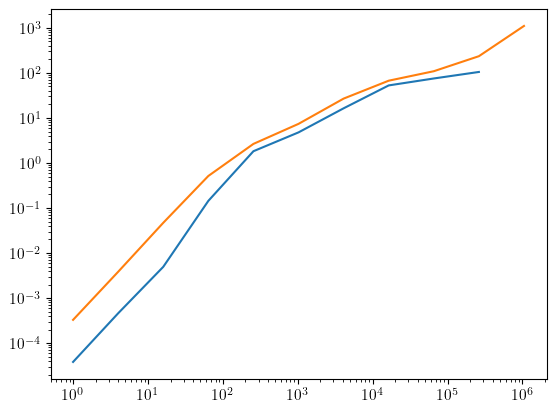

In [89]:
N =1

plt.loglog(sf_5['lags'], sf_5['SF_trace'][N])
plt.loglog(sf_2['lags'], sf_2['SF_trace'][N])

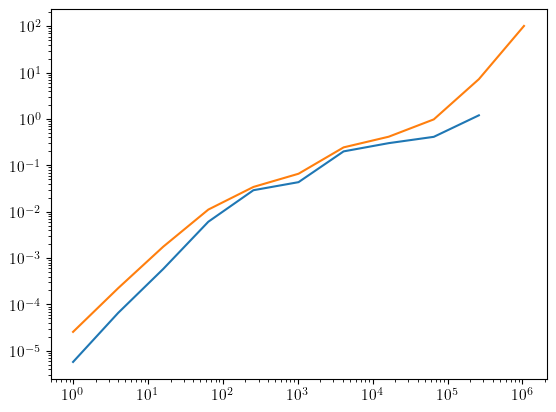

In [91]:
N =1

plt.loglog(sf_5['lags'], sf_5['SF_mod'][N])
plt.loglog(sf_2['lags'], sf_2['SF_mod'][N])

18-Feb-26 10:53:42: C:\Users\nokni\work\MHDTurbPy\functions\general_functions.py:2133: RuntimeWarning: invalid value encountered in sqrt
  erroutt = np.sqrt(erroutt * (1.0 - erroutt) / np.float64(np.size(val)))



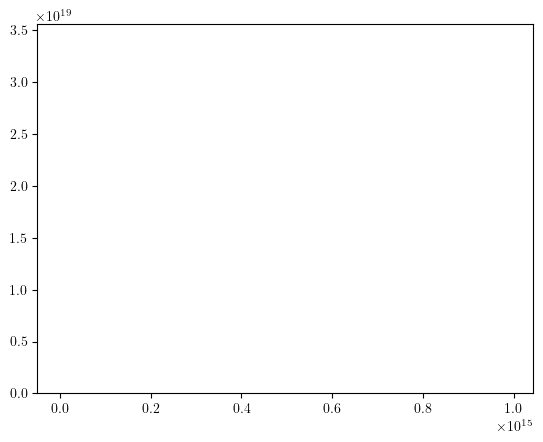

In [15]:
r =func.pdf(s, 100, 1,1)

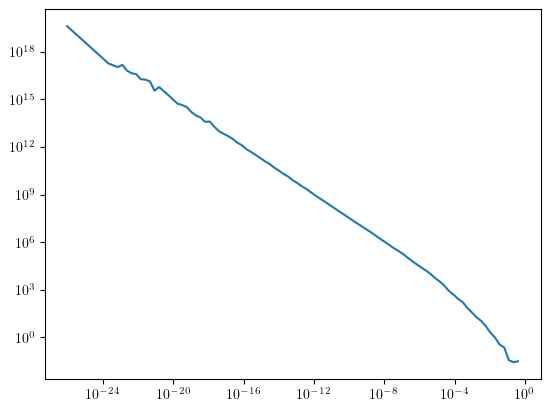

In [13]:
plt.loglog(r[0], r[1])

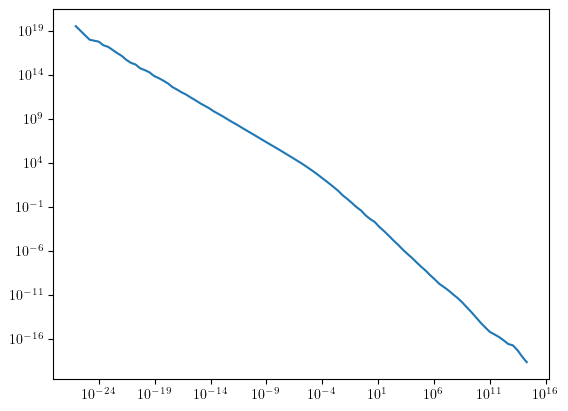

In [16]:
plt.loglog(r[0], r[1])

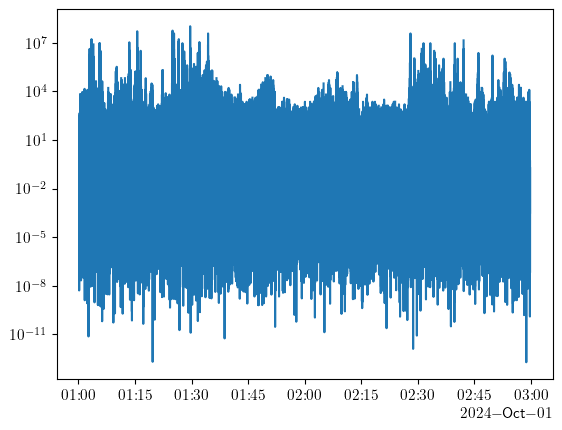

In [48]:

plt.semilogy(s)


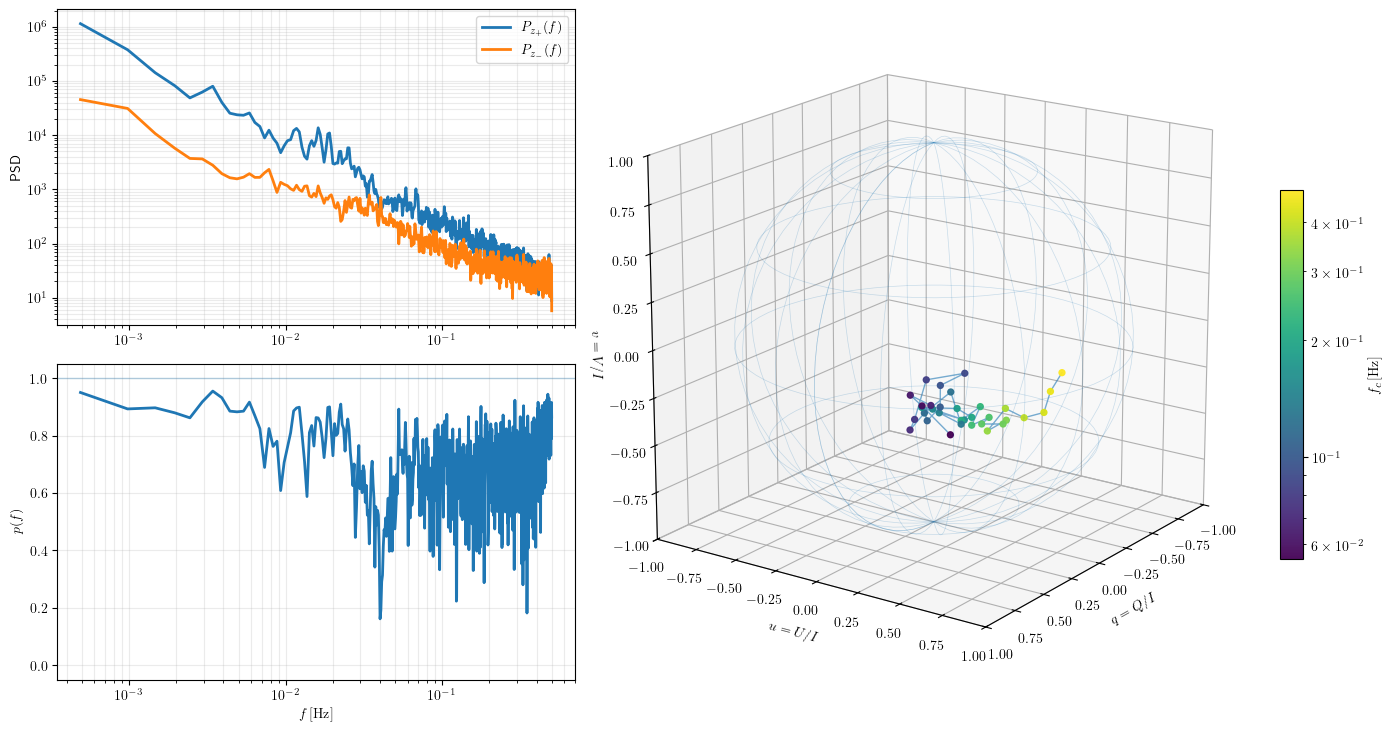

n_segments              = 107
frac(p>1)               = 0.0
CS violation frac       = 0.0
Parseval relerr p50 (+) = 0.37427670338434516
Parseval relerr p50 (-) = 0.3006512263687326
cadence maxdev_rel      = 0.0


In [18]:
# %% [markdown]
# Elsässer Poincaré / polarization pipeline (notebook-ready)
# - segment-averaged quadratic forms (explicit; no black-box Welch)
# - gap-aware (no interpolation)
# - one-sided rFFT normalization with DC/Nyquist handling
# - Stokes-consistent banding for sphere points (sum I,Q,U,V in-band)

# %% 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import Dict, Optional, Sequence, Tuple, List
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm, Normalize
from matplotlib.ticker import LogLocator, FuncFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


# %% 
# ----------------------------
# Utilities
# ----------------------------
def require_columns(sig: pd.DataFrame, cols: Sequence[str]) -> None:
    missing = [c for c in cols if c not in sig.columns]
    if missing:
        raise KeyError("Missing required columns: %s" % missing)


def as_float_array(x) -> np.ndarray:
    if isinstance(x, np.ndarray):
        return x.astype(float)
    return pd.to_numeric(x, errors="coerce").astype(float).values


def infer_dt_from_index(sig: pd.DataFrame) -> float:
    idx = sig.index
    if not isinstance(idx, (pd.DatetimeIndex, pd.TimedeltaIndex)):
        raise ValueError("dt not provided and cannot be inferred (index is not datetime/timedelta).")
    dt = idx.to_series().diff().dt.total_seconds().dropna().values
    if dt.size == 0:
        raise ValueError("Cannot infer dt (empty/degenerate index).")
    dt_med = np.nanmedian(dt)
    if not np.isfinite(dt_med) or dt_med <= 0:
        raise ValueError("Inferred dt is invalid.")
    return float(dt_med)


def cadence_diagnostics(sig: pd.DataFrame) -> Dict[str, float]:
    out = {
        "dt_med": np.nan,
        "dt_mad_rel": np.nan,
        "dt_maxdev_rel": np.nan,
        "dt_min": np.nan,
        "dt_max": np.nan,
    }
    idx = sig.index
    if not isinstance(idx, (pd.DatetimeIndex, pd.TimedeltaIndex)):
        return out
    dts = idx.to_series().diff().dt.total_seconds().values
    dts = dts[np.isfinite(dts)]
    if dts.size == 0:
        return out
    med = float(np.nanmedian(dts))
    mad = float(np.nanmedian(np.abs(dts - med)))
    out["dt_med"] = med
    out["dt_mad_rel"] = float(mad / med) if med > 0 else np.nan
    out["dt_maxdev_rel"] = float(np.nanmax(np.abs(dts - med)) / med) if med > 0 else np.nan
    out["dt_min"] = float(np.nanmin(dts))
    out["dt_max"] = float(np.nanmax(dts))
    return out


def runs_of_true(mask: np.ndarray) -> List[Tuple[int, int]]:
    mask = mask.astype(bool)
    if mask.size == 0:
        return []
    d = np.diff(mask.astype(int))
    starts = np.where(d == 1)[0] + 1
    ends = np.where(d == -1)[0] + 1
    if mask[0]:
        starts = np.r_[0, starts]
    if mask[-1]:
        ends = np.r_[ends, mask.size]
    return list(zip(starts.tolist(), ends.tolist()))


def one_sided_dc_nyquist_factor(nperseg: int) -> np.ndarray:
    """
    If you use TracePSD-style scaling (doubling all rFFT bins),
    multiply by this factor to undo doubling at DC (and Nyquist if even).
    """
    nfreq = nperseg // 2 + 1
    fac = np.ones(nfreq, dtype=float)
    fac[0] = 0.5
    if (nperseg % 2) == 0:
        fac[-1] = 0.5
    return fac


def make_log_bands(
    freqs: np.ndarray,
    nbands: int = 80,
    min_bins_per_band: int = 10,
    fmin: Optional[float] = None,
    fmax: Optional[float] = None,
) -> np.ndarray:
    fpos = freqs[np.isfinite(freqs) & (freqs > 0)]
    if fpos.size < 2 * max(1, min_bins_per_band):
        raise ValueError("Not enough positive frequency bins to form robust bands.")
    lo = float(fpos.min()) if fmin is None else float(fmin)
    hi = float(fpos.max()) if fmax is None else float(fmax)
    if not (0.0 < lo < hi):
        raise ValueError("Invalid (fmin,fmax).")

    max_nbands = max(3, int(fpos.size // max(1, min_bins_per_band)))
    nb = int(min(int(nbands), max_nbands))
    return np.logspace(np.log10(lo), np.log10(hi), nb + 1)


# %%
# ----------------------------
# Core estimator: segment-averaged Stokes spectra
# ----------------------------
def elsasser_polarization_spectra(
    sig: pd.DataFrame,
    dt: Optional[float] = None,
    cols_plus: Sequence[str] = ("Zpr", "Zpt", "Zpn"),
    cols_minus: Sequence[str] = ("Zmr", "Zmt", "Zmn"),
    nperseg: int = 4096,
    noverlap: int = 2048,
    remove_mean: bool = True,
    detrend_linear: bool = False,
    window: Optional[str] = "hann",   # None or "hann"
    gap_factor: float = 5.0,
    fix_dc_nyquist: bool = True,
    cadence_maxdev_rel: float = 0.02,
    compute_parseval: bool = True,
    parseval_max_segments: int = 200,
) -> Dict[str, np.ndarray]:
    """
    Returns (segment-averaged):
      freqs, Pz_plus, Pz_minus, I,Q,U,V,p
    plus diagnostics.
    """
    if dt is None:
        dt = infer_dt_from_index(sig)

    require_columns(sig, list(cols_plus) + list(cols_minus))

    cad = cadence_diagnostics(sig)
    if np.isfinite(cad["dt_maxdev_rel"]) and cad["dt_maxdev_rel"] > float(cadence_maxdev_rel):
        raise ValueError(
            "Cadence too irregular for FFT estimator: max|dt_i-dt|/dt = %.3g > %.3g"
            % (cad["dt_maxdev_rel"], float(cadence_maxdev_rel))
        )

    zp = [as_float_array(sig[c]) for c in cols_plus]
    zm = [as_float_array(sig[c]) for c in cols_minus]

    Ntot = len(zp[0])
    for a in zp[1:] + zm:
        if len(a) != Ntot:
            raise ValueError("Component lengths do not match.")

    good = np.isfinite(zp[0])
    for a in zp[1:] + zm:
        good &= np.isfinite(a)

    if isinstance(sig.index, pd.DatetimeIndex):
        dts = sig.index.to_series().diff().dt.total_seconds().values
        big_gap = np.zeros(Ntot, dtype=bool)
        big_gap[1:] = np.isfinite(dts[1:]) & (dts[1:] > gap_factor * float(dt))
        good[big_gap] = False

    runs = runs_of_true(good)
    if len(runs) == 0:
        raise ValueError("No usable contiguous data (finite + gap handling).")

    step = nperseg - noverlap
    if step <= 0:
        raise ValueError("noverlap must be < nperseg.")

    # window
    if window is None:
        w = None
        Uwin = 1.0
    else:
        if window.lower() != "hann":
            raise ValueError("window must be None or 'hann'.")
        w = np.hanning(nperseg).astype(float)
        Uwin = float(np.mean(w**2))
        if not np.isfinite(Uwin) or Uwin <= 0:
            raise ValueError("Window normalization failed.")

    dcny = one_sided_dc_nyquist_factor(nperseg) if fix_dc_nyquist else np.ones(nperseg // 2 + 1, dtype=float)

    def prep_seg(xseg: np.ndarray) -> np.ndarray:
        x = xseg.astype(float)
        if remove_mean:
            x = x - np.mean(x)
        if detrend_linear:
            t = np.arange(x.size, dtype=float)
            pfit = np.polyfit(t, x, 1)
            x = x - (pfit[0] * t + pfit[1])
        if w is not None:
            x = x * w
        return x

    scale = (2.0 * float(dt)) / float(nperseg)  # TracePSD-style
    df = 1.0 / (float(nperseg) * float(dt))
    freqs = np.fft.rfftfreq(nperseg, float(dt))

    Pp_acc = None
    Pm_acc = None
    C_acc = None
    n_used = 0

    # diagnostics
    parse_rel_err_plus = []
    parse_rel_err_minus = []
    segs_checked = 0

    for (a, b) in runs:
        if (b - a) < nperseg:
            continue
        for start in range(a, b - nperseg + 1, step):
            sl = slice(start, start + nperseg)

            Zp = []
            Zm = []
            for j in range(3):
                Zp.append(np.fft.rfft(prep_seg(zp[j][sl])))
                Zm.append(np.fft.rfft(prep_seg(zm[j][sl])))

            Pp = scale * (np.abs(Zp[0])**2 + np.abs(Zp[1])**2 + np.abs(Zp[2])**2)
            Pm = scale * (np.abs(Zm[0])**2 + np.abs(Zm[1])**2 + np.abs(Zm[2])**2)
            C = scale * (Zp[0] * np.conj(Zm[0]) + Zp[1] * np.conj(Zm[1]) + Zp[2] * np.conj(Zm[2]))

            # window power correction + DC/Nyquist correction
            Pp = (Pp / Uwin) * dcny
            Pm = (Pm / Uwin) * dcny
            C  = (C  / Uwin) * dcny

            if Pp_acc is None:
                Pp_acc = np.zeros_like(Pp, dtype=float)
                Pm_acc = np.zeros_like(Pm, dtype=float)
                C_acc = np.zeros_like(C, dtype=complex)

            Pp_acc += Pp
            Pm_acc += Pm
            C_acc += C
            n_used += 1

            # Parseval sanity (trace), optional
            if compute_parseval and segs_checked < int(parseval_max_segments):
                # compare integral(PSD) to mean(x0^2) where x0 is pre-window (but post-mean/detrend)
                var_p = 0.0
                var_m = 0.0
                for j in range(3):
                    x0p = zp[j][sl].astype(float)
                    x0m = zm[j][sl].astype(float)
                    if remove_mean:
                        x0p = x0p - np.mean(x0p)
                        x0m = x0m - np.mean(x0m)
                    if detrend_linear:
                        t = np.arange(x0p.size, dtype=float)
                        pfitp = np.polyfit(t, x0p, 1)
                        pfitm = np.polyfit(t, x0m, 1)
                        x0p = x0p - (pfitp[0] * t + pfitp[1])
                        x0m = x0m - (pfitm[0] * t + pfitm[1])
                    var_p += float(np.mean(x0p**2))
                    var_m += float(np.mean(x0m**2))

                int_p = float(np.sum(Pp) * df)
                int_m = float(np.sum(Pm) * df)
                if var_p > 0:
                    parse_rel_err_plus.append(abs(int_p - var_p) / var_p)
                if var_m > 0:
                    parse_rel_err_minus.append(abs(int_m - var_m) / var_m)
                segs_checked += 1

    if n_used == 0:
        raise ValueError("No segments used. Check nperseg/noverlap and gaps.")

    Pz_plus = Pp_acc / float(n_used)
    Pz_minus = Pm_acc / float(n_used)
    Cbar = C_acc / float(n_used)

    I = Pz_plus + Pz_minus
    Q = Pz_plus - Pz_minus
    Uv = 2.0 * np.real(Cbar)
    Vv = 2.0 * np.imag(Cbar)

    p = np.full_like(I, np.nan, dtype=float)
    ok = np.isfinite(I) & (I > 0) & np.isfinite(Q) & np.isfinite(Uv) & np.isfinite(Vv)
    p[ok] = np.sqrt(Q[ok]**2 + Uv[ok]**2 + Vv[ok]**2) / I[ok]

    # Cauchy–Schwarz diagnostic: |C|^2 <= E+ E-
    cs_ok = np.isfinite(Pz_plus) & np.isfinite(Pz_minus) & (Pz_plus >= 0) & (Pz_minus >= 0) & np.isfinite(Cbar)
    cs_violate_frac = np.nan
    if np.any(cs_ok):
        cs_violate = (np.abs(Cbar[cs_ok])**2) > (Pz_plus[cs_ok] * Pz_minus[cs_ok]) * (1.0 + 1e-6)
        cs_violate_frac = float(np.mean(cs_violate))

    frac_p_gt_1 = float(np.mean(ok & (p > 1.0 + 1e-6))) if np.any(ok) else np.nan

    def _p50(x: List[float]) -> float:
        return float(np.nanmedian(x)) if len(x) else np.nan

    def _p95(x: List[float]) -> float:
        return float(np.nanpercentile(x, 95)) if len(x) else np.nan

    return {
        "freqs": freqs,
        "Pz_plus": Pz_plus,
        "Pz_minus": Pz_minus,
        "C": Cbar,
        "I": I, "Q": Q, "U": Uv, "V": Vv,
        "p": p,
        "qf": np.where(ok, Q / I, np.nan),
        "uf": np.where(ok, Uv / I, np.nan),
        "vf": np.where(ok, Vv / I, np.nan),
        "diag_n_segments": np.array([int(n_used)], dtype=int),
        "diag_frac_p_gt_1": np.array([frac_p_gt_1], dtype=float),
        "diag_cs_violate_frac": np.array([cs_violate_frac], dtype=float),
        "diag_parseval_relerr_p50_plus": np.array([_p50(parse_rel_err_plus)], dtype=float),
        "diag_parseval_relerr_p95_plus": np.array([_p95(parse_rel_err_plus)], dtype=float),
        "diag_parseval_relerr_p50_minus": np.array([_p50(parse_rel_err_minus)], dtype=float),
        "diag_parseval_relerr_p95_minus": np.array([_p95(parse_rel_err_minus)], dtype=float),
        "diag_dt": np.array([float(dt)], dtype=float),
        "diag_dt_mad_rel": np.array([float(cad["dt_mad_rel"])], dtype=float),
        "diag_dt_maxdev_rel": np.array([float(cad["dt_maxdev_rel"])], dtype=float),
        "diag_fix_dc_nyquist": np.array([1.0 if fix_dc_nyquist else 0.0], dtype=float),
        "diag_window": np.array([0.0 if window is None else 1.0], dtype=float),
    }


# %%
# ----------------------------
# Banding for Poincaré sphere (Stokes-consistent)
# ----------------------------
def poincare_points_from_bands(
    spec: Dict[str, np.ndarray],
    f_edges: np.ndarray,
    min_bins_in_band: int = 8,
) -> Dict[str, np.ndarray]:
    f = spec["freqs"]
    I = spec["I"]; Q = spec["Q"]; U = spec["U"]; V = spec["V"]

    nb = len(f_edges) - 1
    q = np.full(nb, np.nan)
    u = np.full(nb, np.nan)
    v = np.full(nb, np.nan)
    p = np.full(nb, np.nan)
    fc = np.full(nb, np.nan)
    nbin = np.zeros(nb, dtype=int)
    Iband = np.full(nb, np.nan)

    for i in range(nb):
        f1 = float(f_edges[i])
        f2 = float(f_edges[i + 1])
        m = (f >= f1) & (f < f2) & np.isfinite(I) & (I > 0) & np.isfinite(Q) & np.isfinite(U) & np.isfinite(V)
        nn = int(np.sum(m))
        nbin[i] = nn
        if nn < int(min_bins_in_band):
            continue

        # Stokes mixture: sum in-band then normalize
        Ibar = float(np.sum(I[m]))
        if not np.isfinite(Ibar) or Ibar <= 0:
            continue
        Qbar = float(np.sum(Q[m]))
        Ubar = float(np.sum(U[m]))
        Vbar = float(np.sum(V[m]))

        q[i] = Qbar / Ibar
        u[i] = Ubar / Ibar
        v[i] = Vbar / Ibar
        p[i] = np.sqrt(q[i]**2 + u[i]**2 + v[i]**2)
        fc[i] = np.sqrt(f1 * f2)
        Iband[i] = Ibar

    return {"fc": fc, "q": q, "u": u, "v": v, "p": p, "nbin": nbin, "Iband": Iband}


# %%
# ----------------------------
# Composite plot (trace PSDs + p(f) + sphere)
# ----------------------------
def plot_spectra_and_sphere(
    spec: Dict[str, np.ndarray],
    pts: Dict[str, np.ndarray],
    color_by: str = "fc",            # "fc" or "p"
    project_to_unit: bool = False,   # if True: plot on unit sphere
    cmap: str = "viridis",
    elev: float = 18.0,
    azim: float = 35.0,
    connect: bool = True,
    point_size: float = 18.0,
    point_alpha: float = 0.95,
    sphere_wire_alpha: float = 0.22,
    outfile: Optional[str] = None,
) -> None:
    f = spec["freqs"]
    Pp = spec["Pz_plus"]
    Pm = spec["Pz_minus"]
    pf = spec["p"]

    q = pts["q"].copy()
    u = pts["u"].copy()
    v = pts["v"].copy()
    fc = pts["fc"].copy()
    pb = pts["p"].copy()

    mpts = np.isfinite(q) & np.isfinite(u) & np.isfinite(v) & np.isfinite(fc) & np.isfinite(pb)
    q, u, v, fc, pb = q[mpts], u[mpts], v[mpts], fc[mpts], pb[mpts]

    if project_to_unit:
        keep = (pb > 0) & np.isfinite(pb)
        q, u, v, fc, pb = q[keep], u[keep], v[keep], fc[keep], pb[keep]
        q = q / pb
        u = u / pb
        v = v / pb

    fig = plt.figure(figsize=(12.6, 7.2), constrained_layout=True)
    gs = GridSpec(2, 2, figure=fig, width_ratios=[1.0, 1.30])

    ax_psd = fig.add_subplot(gs[0, 0])
    ax_p = fig.add_subplot(gs[1, 0], sharex=ax_psd)
    ax_s = fig.add_subplot(gs[:, 1], projection="3d")

    m = (f > 0) & np.isfinite(Pp) & np.isfinite(Pm)
    ax_psd.loglog(f[m], Pp[m], linewidth=2.0, label=r"$P_{z_+}(f)$")
    ax_psd.loglog(f[m], Pm[m], linewidth=2.0, label=r"$P_{z_-}(f)$")
    ax_psd.set_ylabel("PSD")
    ax_psd.grid(True, which="both", alpha=0.25)
    ax_psd.legend(loc="best")

    mp = m & np.isfinite(pf)
    ax_p.semilogx(f[mp], pf[mp], linewidth=2.0)
    ax_p.axhline(1.0, linewidth=1.0, alpha=0.3)
    ax_p.set_xlabel(r"$f\,[\mathrm{Hz}]$")
    ax_p.set_ylabel(r"$p(f)$")
    ax_p.set_ylim(-0.05, 1.05)
    ax_p.grid(True, which="both", alpha=0.25)

    th = np.linspace(0.0, np.pi, 36)
    ph = np.linspace(0.0, 2.0 * np.pi, 72)
    TH, PH = np.meshgrid(th, ph)
    X = np.sin(TH) * np.cos(PH)
    Y = np.sin(TH) * np.sin(PH)
    Z = np.cos(TH)
    ax_s.plot_wireframe(X, Y, Z, rstride=4, cstride=6, linewidth=0.5, alpha=sphere_wire_alpha)

    if color_by == "p":
        cval = pb
        norm = Normalize(vmin=0.0, vmax=1.0)
        cbar_label = r"$p_{\mathrm{band}}$"
    else:
        cval = fc
        vmin = float(np.nanmin(cval))
        vmax = float(np.nanmax(cval))
        norm = LogNorm(vmin=vmin, vmax=vmax)
        cbar_label = r"$f_c\,[\mathrm{Hz}]$"

    sc = ax_s.scatter(q, u, v, c=cval, cmap=cmap, norm=norm,
                      s=point_size, alpha=point_alpha, depthshade=True)

    if connect and fc.size > 1:
        order = np.argsort(fc)
        ax_s.plot(q[order], u[order], v[order], linewidth=1.0, alpha=0.6)

    ax_s.set_xlabel(r"$q=Q/I$")
    ax_s.set_ylabel(r"$u=U/I$")
    ax_s.set_zlabel(r"$v=V/I$")
    ax_s.set_xlim(-1, 1)
    ax_s.set_ylim(-1, 1)
    ax_s.set_zlim(-1, 1)
    ax_s.view_init(elev=elev, azim=azim)
    try:
        ax_s.set_box_aspect((1, 1, 1))
    except Exception:
        pass

    cax = inset_axes(ax_s, width="3.5%", height="55%",
                     loc="lower left",
                     bbox_to_anchor=(1.03, 0.18, 1, 1),
                     bbox_transform=ax_s.transAxes,
                     borderpad=0.0)
    cbar = fig.colorbar(sc, cax=cax)
    cbar.set_label(cbar_label)

    if color_by != "p":
        cbar.locator = LogLocator(base=10.0, subs=(1.0,))
        cbar.formatter = FuncFormatter(
            lambda x, pos: r"$10^{%d}$" % int(np.round(np.log10(x))) if x > 0 else ""
        )
        cbar.update_ticks()
    else:
        cbar.set_ticks([0.0, 0.25, 0.5, 0.75, 1.0])

    if outfile is not None:
        fig.savefig(outfile, bbox_inches="tight")

    plt.show()


# %%
# ----------------------------
# One-call pipeline
# ----------------------------
def run_elsasser_poincare_pipeline(
    sig: pd.DataFrame,
    dt: Optional[float] = None,
    cols_plus: Sequence[str] = ("Zpr", "Zpt", "Zpn"),
    cols_minus: Sequence[str] = ("Zmr", "Zmt", "Zmn"),
    nperseg: int = 4096,
    noverlap: int = 2048,
    window: Optional[str] = "hann",
    remove_mean: bool = True,
    detrend_linear: bool = False,
    gap_factor: float = 5.0,
    fix_dc_nyquist: bool = True,
    cadence_maxdev_rel: float = 0.02,
    nbands: int = 120,
    min_bins_per_band: int = 10,
    min_bins_in_band: int = 8,
    fmin: Optional[float] = None,
    fmax: Optional[float] = None,
    color_by: str = "fc",
    project_to_unit: bool = False,
    outfile: Optional[str] = None,
) -> Dict[str, Dict[str, np.ndarray]]:
    spec = elsasser_polarization_spectra(
        sig=sig,
        dt=dt,
        cols_plus=cols_plus,
        cols_minus=cols_minus,
        nperseg=nperseg,
        noverlap=noverlap,
        remove_mean=remove_mean,
        detrend_linear=detrend_linear,
        window=window,
        gap_factor=gap_factor,
        fix_dc_nyquist=fix_dc_nyquist,
        cadence_maxdev_rel=cadence_maxdev_rel,
    )

    edges = make_log_bands(
        spec["freqs"],
        nbands=nbands,
        min_bins_per_band=min_bins_per_band,
        fmin=fmin,
        fmax=fmax,
    )
    pts = poincare_points_from_bands(spec, edges, min_bins_in_band=min_bins_in_band)

    plot_spectra_and_sphere(
        spec,
        pts,
        color_by=color_by,
        project_to_unit=project_to_unit,
        outfile=outfile,
    )

    return {"spec": spec, "pts": pts, "f_edges": edges}


# %% [markdown]
# ## Run on your provided `sig` DataFrame

# %%
# Expect `sig` to exist already as a DataFrame with columns:
#   Zpr,Zpt,Zpn and Zmr,Zmt,Zmn
#
# Example:
# out = run_elsasser_poincare_pipeline(sig, nperseg=4096, noverlap=2048, outfile="elsasser_poincare.pdf")

out = run_elsasser_poincare_pipeline(
    sig,
    dt=None,
    cols_plus=("Zpr", "Zpt", "Zpn"),
    cols_minus=("Zmr", "Zmt", "Zmn"),
    nperseg=2048,
    noverlap=2000,
    window="hann",
    gap_factor=5.0,
    fix_dc_nyquist=True,
    cadence_maxdev_rel=0.02,
    nbands=120,
    min_bins_per_band=10,
    min_bins_in_band=8,
    color_by="fc",
    project_to_unit=False,
    outfile="elsasser_poincare.pdf",
)

spec = out["spec"]
print("n_segments              =", int(spec["diag_n_segments"][0]))
print("frac(p>1)               =", float(spec["diag_frac_p_gt_1"][0]))
print("CS violation frac       =", float(spec["diag_cs_violate_frac"][0]))
print("Parseval relerr p50 (+) =", float(spec["diag_parseval_relerr_p50_plus"][0]))
print("Parseval relerr p50 (-) =", float(spec["diag_parseval_relerr_p50_minus"][0]))
print("cadence maxdev_rel      =", float(spec["diag_dt_maxdev_rel"][0]))


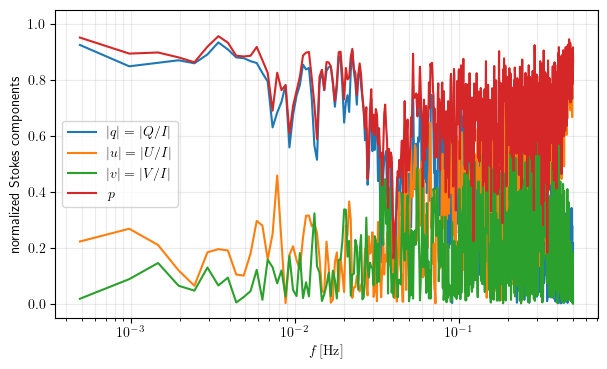

In [24]:
# %%
f = spec["freqs"]
m = (f > 0) & np.isfinite(spec["qf"]) & np.isfinite(spec["uf"]) & np.isfinite(spec["vf"])

plt.figure(figsize=(7.0, 4.0))
plt.semilogx(f[m], np.abs(spec["qf"][m]), label=r"$|q|=|Q/I|$")
plt.semilogx(f[m], np.abs(spec["uf"][m]), label=r"$|u|=|U/I|$")
plt.semilogx(f[m], np.abs(spec["vf"][m]), label=r"$|v|=|V/I|$")
plt.semilogx(f[m], spec["p"][m], label=r"$p$")
plt.ylim(-0.05, 1.05)
plt.xlabel(r"$f\,[\mathrm{Hz}]$")
plt.ylabel("normalized Stokes components")
plt.grid(True, which="both", alpha=0.25)
plt.legend(loc="best")
plt.show()


In [5]:
fin['Par']['V_resampled']

,np,Vr,Vt,Vn,sc_vel_r,sc_vel_t,sc_vel_n,Tp,Vth,np_qtn,ne_qtn,Dist_au
datetime,,,,,,,,,,,,
2024-10-01 01:00:10,99.960030,440.975952,74.862923,-37.918549,0.655268,67.528183,8.922450,22.685862,65.924820,99.960030,99.960030,NaN
2024-10-01 01:00:11,101.939735,440.834503,76.732918,-36.978939,0.655305,67.528183,8.922455,23.161848,66.612839,101.939735,101.939735,NaN
2024-10-01 01:00:12,101.866364,440.927765,76.435883,-36.609089,0.655341,67.528183,8.922460,22.795553,66.084007,101.866364,101.866364,NaN
2024-10-01 01:00:13,101.781075,440.842743,77.163132,-37.149250,0.655378,67.528175,8.922464,22.950142,66.307709,101.781075,101.781075,NaN
2024-10-01 01:00:14,103.412003,440.895142,75.721138,-35.977959,0.655415,67.528175,8.922469,23.511761,67.114120,103.412003,103.412003,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-01 02:59:43,72.189629,391.342194,-18.355389,-14.386876,0.918680,67.514862,8.956159,14.900815,53.428913,72.189629,72.189629,NaN
2024-10-01 02:59:44,74.050529,389.283966,-10.701035,-10.746937,0.918717,67.514862,8.956163,14.845004,53.328758,74.050529,74.050529,NaN
2024-10-01 02:59:45,74.059814,388.710052,-6.736063,-12.698762,0.918754,67.514854,8.956167,14.766320,53.187241,74.059814,74.059814,NaN


In [30]:

B_clean, info = turb.remove_wheel_noise_SOLO(
    B, fs,
    plot=True,
    return_debug=True,
    srf_apply_to=[0],   # ONLY if you *want* SRF-family edits on that specific channel
)


array([67.071754, 67.087234, 67.09546 , ..., 50.49808 , 50.506203,
       50.510086], dtype=float32)

In [6]:
#c  = turb.TracePSD(B_clean.T[0],B_clean.T[0],B_clean.T[0],fs)
o  = turb.TracePSD(B.Br.values,B.Br.values,B.Br.values,fs)

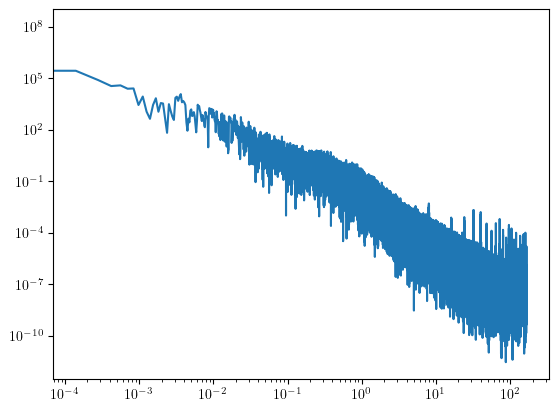

In [7]:
plt.loglog(o[0], o[1])

NameError: name 'c' is not defined

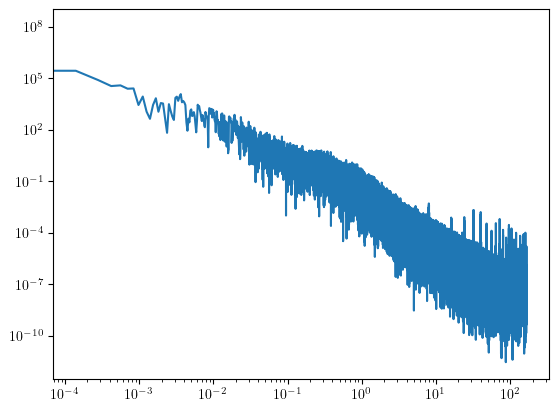

In [6]:
import matplotlib.pyplot as plt

plt.loglog(o[0], o[1])
plt.loglog(c[0], c[1], alpha=0.6)

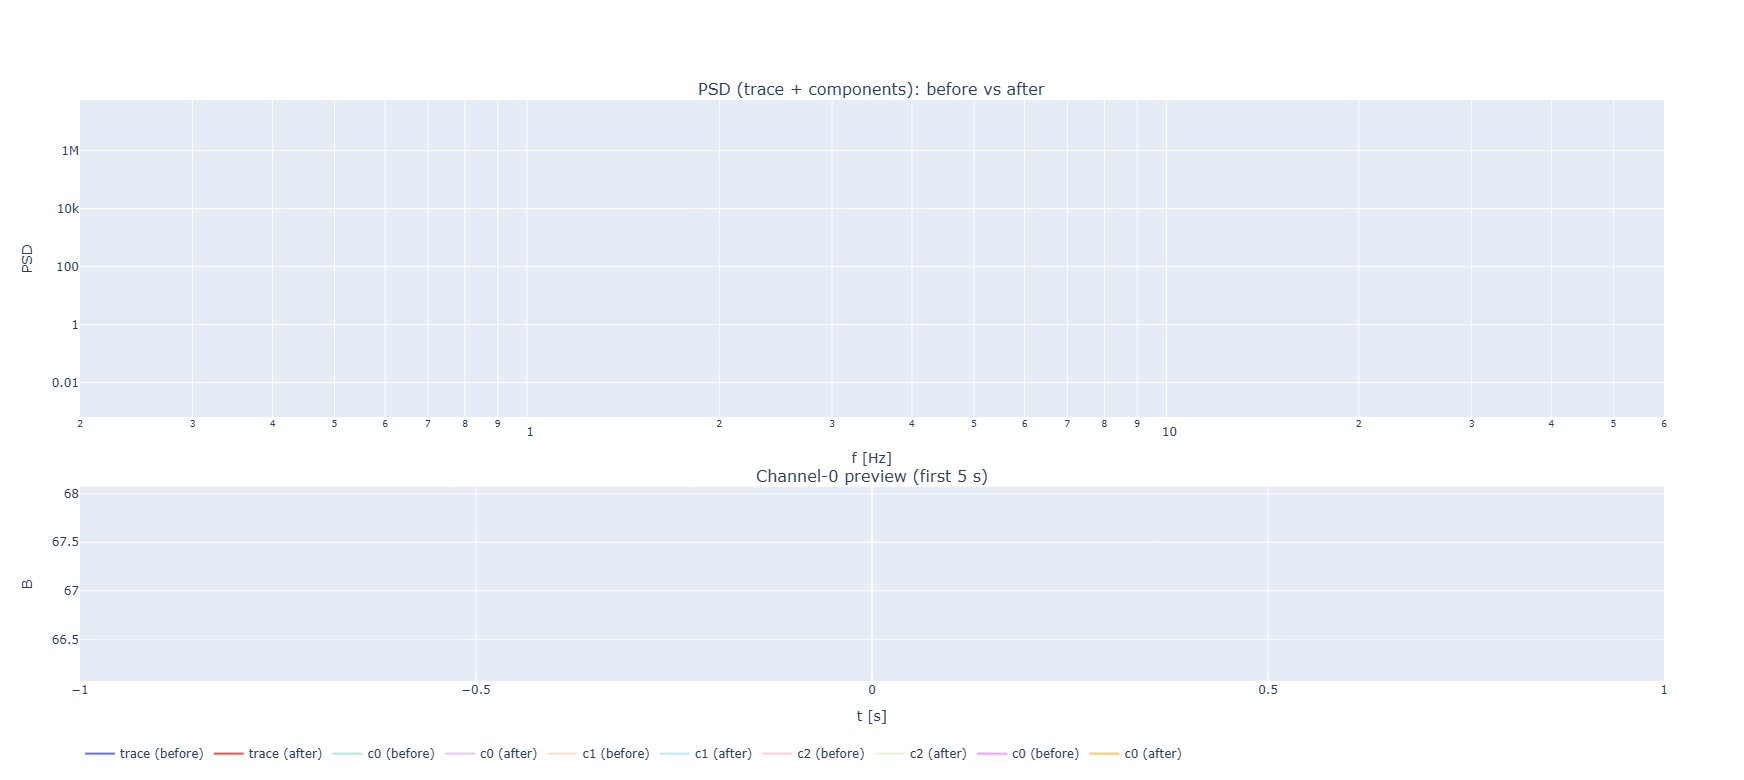

In [32]:
import plotly.io as pio
print("plotly renderer =", pio.renderers.default)


plotly renderer = plotly_mimetype


OSError: [Errno 22] Invalid argument: '\\Users\\nokni\\work\\MHDTurbPy\\examples\\figures\\2024_10_01_2024_10_01_<mpl_toolkits.mplot3d.art3d.Path3DCollection object at 0x0000023696916850>.png'

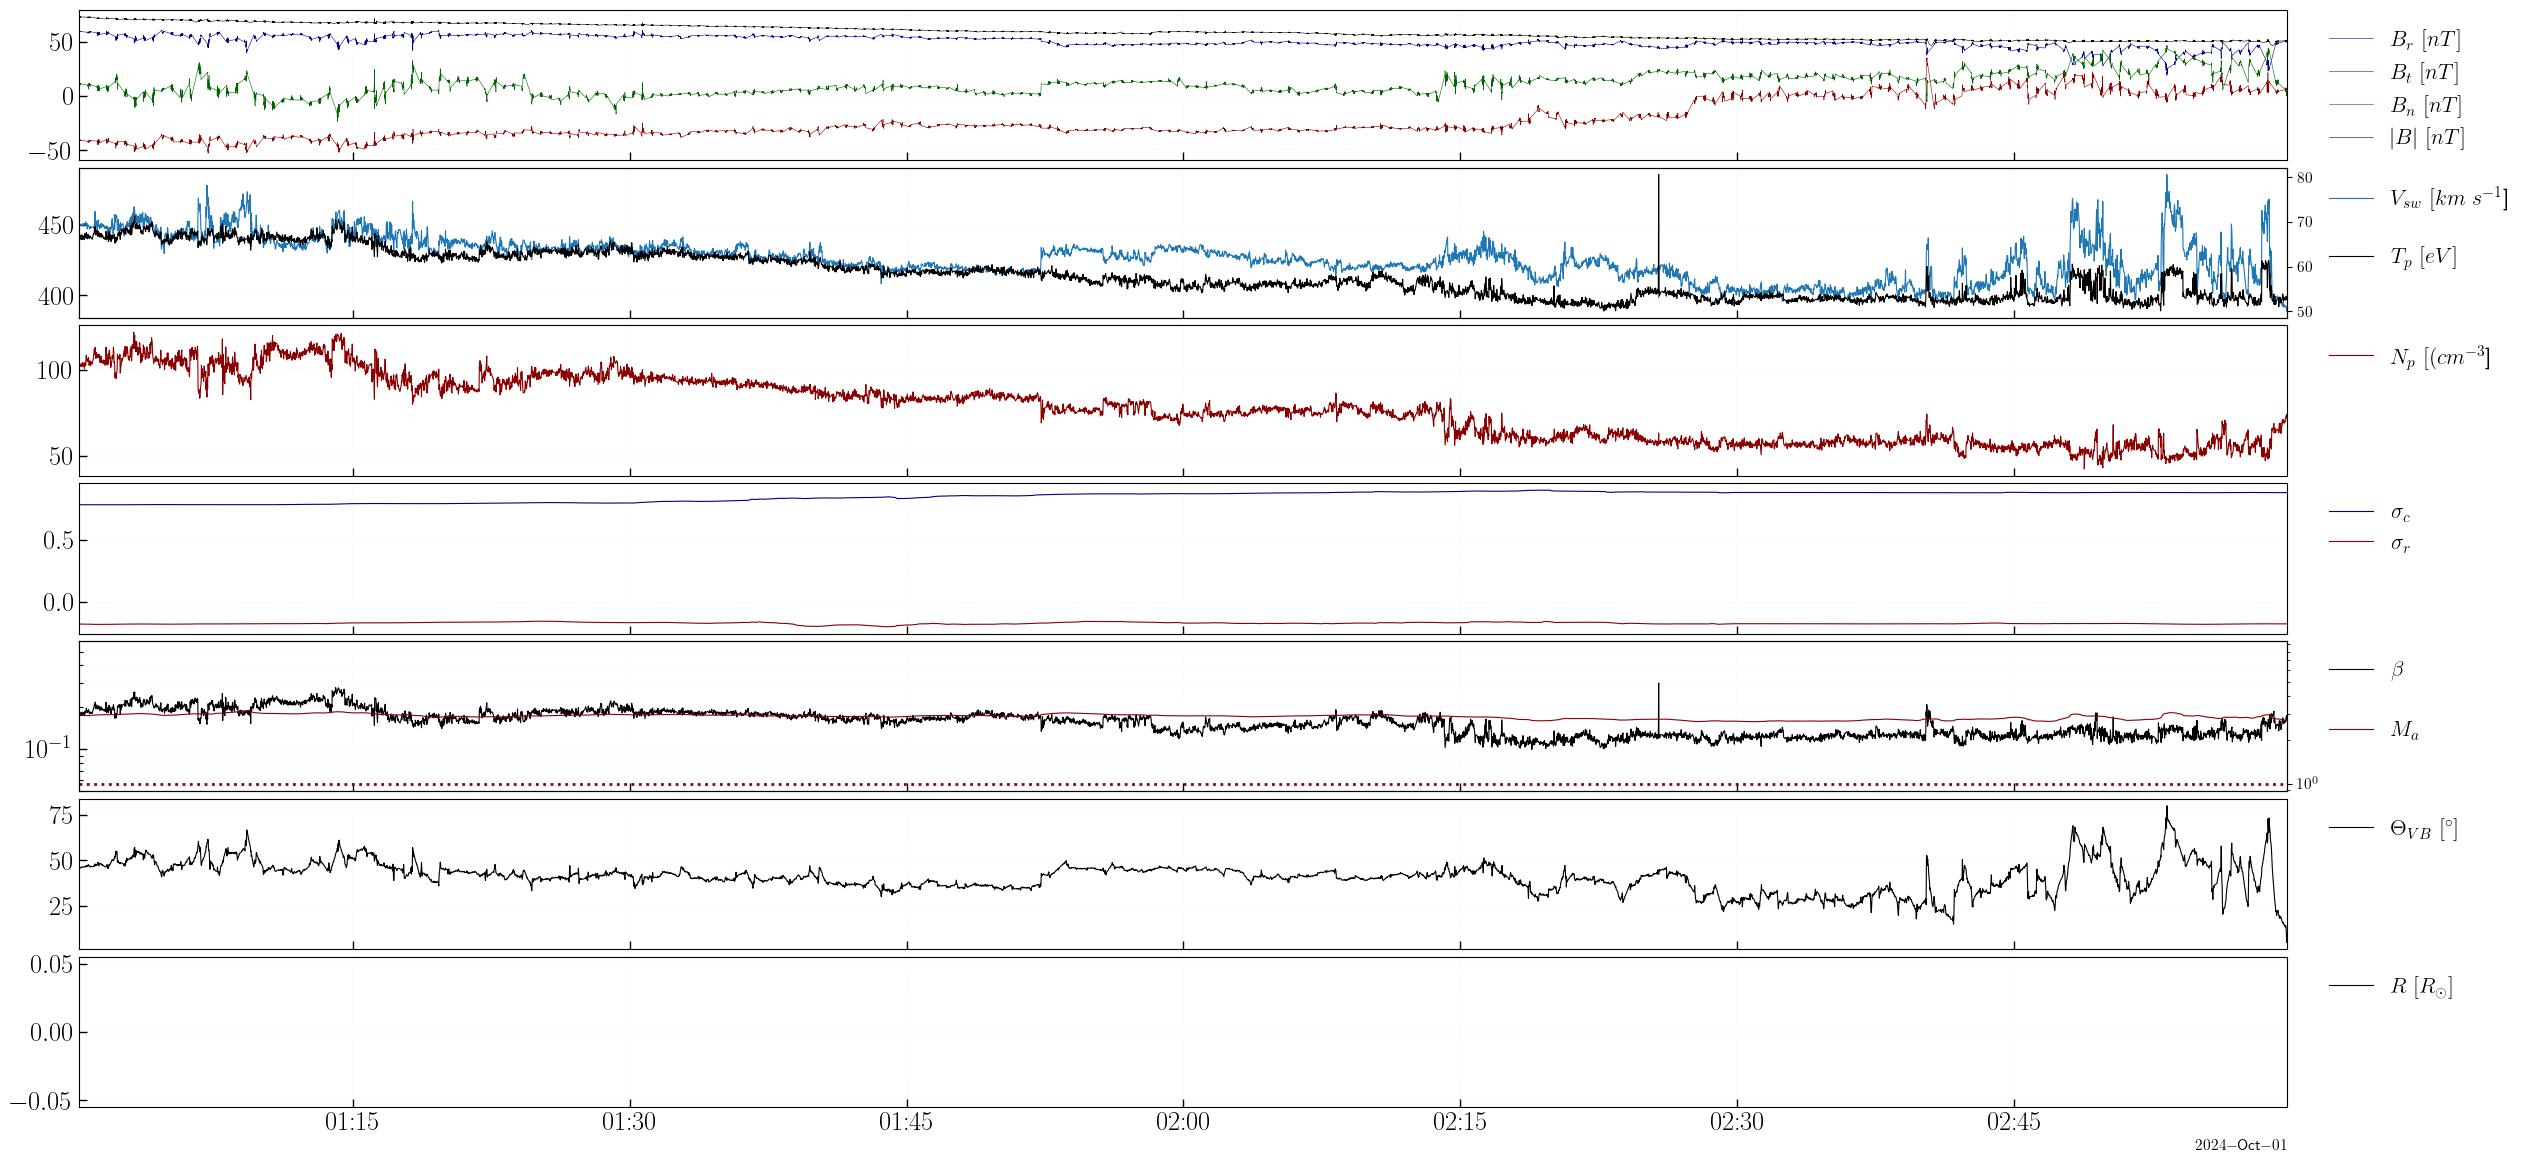

In [31]:
# user defined parameters

label_size        = 21                                    # labels etc

n_subplots        = 7                                     # number os subplots
my_dir            = '/Users/nokni/work/MHDTurbPy/examples/' #
format_2_return   = "%Y_%m_%d"                            # Format to save figures


figs.visualize_downloaded_intervals(
                                  sc                         ,
                                  fin['Par']['V_resampled'],
                                  fin['Mag']['B_resampled'],
                                  sig     ,
                                  my_dir,
                                  format_2_return  = "%Y_%m_%d",  #
                                  size             = label_size,
                                  numb_subplots    = n_subplots
                                 )



# Run with interactive figure

In [5]:
%matplotlib tk

from pathlib import Path
import matplotlib.pyplot as plt
from functions import interactive_figs
from functions import general_functions as func

plt.close("all")

sc = "SOLO"
which_int = 0
load_path = r"C:\Users\nokni\work\MHDTurbPy\examples\SOLO"
my_dir   = r"C:\Users\nokni\work\MHDTurbPy\examples"
save_path = Path(my_dir) / "selected_intervals"

# ============================================================
# ONE run that does BOTH:
# (A) add one extra curve to an existing panel (panel 0)
# (B) append a brand-new extra panel (8th subplot)
# ============================================================
panel_edits = {
    # (A) add one extra curve to an existing panel
    "add_series": {
        "panel_idx": 0,   # top panel
        "axis_idx": 0,    # first axis-spec in that panel (left axis)
        "series": {
            "kind": "col",
            "col": "B_RTN",
            "label": r"$|B|$ (extra dashed)",
            "style": {"lw": 1.0, "ls": "--", "ms": 0, "color": "0.35"},
        },
    },

    # (B) append a new panel at the bottom
    "add_panels": {
        "where": "append",
        "panel": {
            "axes": [
                {
                    "axis_id": "left",
                    "source": "Par",
                    "scale": "linear",
                    "series": [
                        {
                            "kind": "col",
                            "col": "Vth",
                            "label": r"$T_p~[eV]$ (extra panel)",
                            "style": {"lw": 0.8, "ls": "-", "ms": 0, "color": "k"},
                        }
                    ],
                    "legend": {"fontsize": "small", "frameon": False, "bbox_to_anchor": (1.01, 1), "loc": 2},
                    "hline": [{"y": 100.0, "ls": ":", "c": "0.3", "lw": 1.2}],
                }
            ]
        },
    },

    # (c) More

    
}

fig, events = interactive_figs.interactive_mhdturbpy_interval(
    sc=sc,
    which_int=which_int,
    load_path=load_path,
    my_dir=my_dir,
    save_path=save_path,
    rolling=None,
    resample_rule=None,
    fill_method=None,
    gap_thresholds={"mag": "30s", "par": "30s", "qtn": "30s", "sc_pot": "30s"},
    load_files_func=func.load_files,
    autosave=True,
    resume=True,
    export_csv=True,
    snap_to_data=False,
    enable_comments=True,
    debug_interaction=True,
    panel_config=None,          # use defaults
    panel_edits=panel_edits,    # add curve + append panel
    auto_ylims=True,
    debug_plot_config=True,     # should print n_panels=8
)

plt.show()


[plot] n_panels=8
[picker] resumed 3 intervals from C:\Users\nokni\work\MHDTurbPy\examples\selected_intervals\selected_intervals_2024_10_10_2024_10_10_SOLO.pkl
installed mpl(cids=16,None,17,18) + tkbinds=3MHDTurbPy\examples\selected_intervals\selected_intervals_2024_10_10_2024_10_10_SOLO.pkl

[picker] left_select_fallback(default)=True  (toggle with 'l')s\selected_intervals\selected_intervals_2024_10_10_2024_10_10_SOLO.pkl


dedupe_ms=250  dedupe_tol_ns=5000000  span_axes=8 marker_axes=10  move_throttle_ms=33  use_release_event=False0_10_SOLO.pkl





In [13]:
# ---------- User configuration ----------
cdf_lib_path = "/Applications/cdf/cdf/lib"  # update for your machine if needed
credentials = None

# Scan window (end is exclusive for daily slicing)
start_date = "2022-10-01 00:00"
end_date   = "2025-11-01 00:00"

# SOAR merged product options
SOLO_merged_fs = 256  # 256 or 4096
in_rtn = 1            # 1 -> RTN product, 0 -> SRF product

# Save options
save_usual_files = True
save_base = Path(root_dir) / "examples" / "downloaded_intervals" / "SOLO_merged_MAG_daily"
save_base.mkdir(parents=True, exist_ok=True)

settings = {
    "Data_path": Path(root_dir) / "data",
    "save_destination": Path(root_dir) / "examples" / "downloaded_intervals",
    "sc": "SOLO",
    "in_rtn": in_rtn,
    "use_local_data": False,

    # daily non-overlapping intervals
    "start_date": start_date,
    "end_date": end_date,
    "multiple_intervals": False,
    "duration": "24H",
    "Step": "24H",
    "addit_time_around": 1,

    # 1-minute products
    "part_resol": 60,
    "MAG_resol": 60,
    "upsample_low_freq_ts": False,

    "overwrite_files": 1,
    "must_have_qtn": False,
    "Max_par_missing": 30,
    "gap_time_threshold": 5,
    "save_all": True,

    "estimate_derived_param": True,
    "rol_window": "60min",

    # Required by your request
    "SOLO_use_merged_MAG": True,
    "SOLO_merged_fs": SOLO_merged_fs,

    "Big_Gaps": {
        "E_big_gaps": 10,
        "SC_pot_big_gaps": 10,
        "Mag_big_gaps": 500,
        "Par_big_gaps": 500,
        "QTN_big_gaps": 10,
    },

    "cut_in_small_windows": {
        "flag": False,
        "njobs": 1,
        "Step": "5s",
        "duration": "30s",
    },
}

vars_2_downnload = {"mag": None, "swa": None, "rpw": None, "ephem": None}

frame = "rtn" if in_rtn else "srf"
merged_product = f"multi-mag-rpw-scm-merged-{frame}-{SOLO_merged_fs}"
settings["SOLO_merged_product"] = merged_product

print("Save path:", save_base)
print("Merged product:", merged_product)

     


Save path: C:\Users\nokni\work\MHDTurbPy\examples\downloaded_intervals\SOLO_merged_MAG_daily
Merged product: multi-mag-rpw-scm-merged-rtn-256


In [14]:
import pandas as pd

# Daily non-overlapping intervals
start_ts = pd.Timestamp(start_date)
end_ts = pd.Timestamp(end_date)

edges = pd.date_range(start=start_ts, end=end_ts, freq="1D")
if len(edges) < 2:
    raise ValueError("Need at least 1 full day in [start_date, end_date].")

intervals = pd.DataFrame({"Start": edges[:-1], "End": edges[1:]})
print(f"Generated {len(intervals)} daily intervals.")
intervals.head()

Generated 1127 daily intervals.


,Start,End
0,2022-10-01,2022-10-02
1,2022-10-02,2022-10-03
2,2022-10-03,2022-10-04
3,2022-10-04,2022-10-05
4,2022-10-05,2022-10-06


In [15]:
def precheck_soar_availability(interval_df, product):
    rows = []
    try:
        from sunpy.net import Fido
        import sunpy.net.attrs as a
        import sunpy_soar  # noqa: F401
        soar_ok = True
    except Exception as e:
        print("SOAR metadata pre-check unavailable:", e)
        print("Falling back to full-run candidates for all days.")
        soar_ok = False

    if not soar_ok:
        for _, r in interval_df.iterrows():
            rows.append({
                "Start": r["Start"],
                "End": r["End"],
                "soar_available": 1,
                "soar_n_records": np.nan,
            })
        return pd.DataFrame(rows)

    for _, r in interval_df.iterrows():
        t0 = pd.Timestamp(r["Start"])
        t1 = pd.Timestamp(r["End"])

        try:
            qr = Fido.search(a.Time(t0, t1), a.soar.Product(product))
            nrec = len(qr)
            available = int(nrec > 0)
        except Exception:
            nrec = np.nan
            available = 0

        rows.append({
            "Start": t0,
            "End": t1,
            "soar_available": available,
            "soar_n_records": nrec,
        })

    return pd.DataFrame(rows)


precheck = precheck_soar_availability(intervals, merged_product)
print(
    f"SOAR candidate days: {int(precheck.soar_available.sum())}/{len(precheck)}"
)
precheck.head(20)

     

SOAR candidate days: 1127/1127


,Start,End,soar_available,soar_n_records
0,2022-10-01,2022-10-02,1,1
1,2022-10-02,2022-10-03,1,1
2,2022-10-03,2022-10-04,1,1
3,2022-10-04,2022-10-05,1,1
4,2022-10-05,2022-10-06,1,1
5,2022-10-06,2022-10-07,1,1
6,2022-10-07,2022-10-08,1,1
7,2022-10-08,2022-10-09,1,1
8,2022-10-09,2022-10-10,1,1
9,2022-10-10,2022-10-11,1,1


In [16]:
precheck

,Start,End,soar_available,soar_n_records
0,2022-10-01,2022-10-02,1,1
1,2022-10-02,2022-10-03,1,1
2,2022-10-03,2022-10-04,1,1
3,2022-10-04,2022-10-05,1,1
4,2022-10-05,2022-10-06,1,1
...,...,...,...,...
1122,2025-10-27,2025-10-28,1,1
1123,2025-10-28,2025-10-29,1,1
1124,2025-10-29,2025-10-30,1,1
1125,2025-10-30,2025-10-31,1,1


In [47]:
# run_interactive_interval.py
#
# Minimal driver for MHDTurbPy interval visualization.

from importlib import reload
from pathlib import Path

import matplotlib
matplotlib.use("TkAgg")  # notebook: use %matplotlib tk

import matplotlib.pyplot as plt

import interactive_figs as ifigs
import general_functions as func

reload(ifigs)
plt.close("all")

ROOT = Path(r"C:\Users\nokni\work\MHDTurbPy")  # <-- edit this once

SC = ["SOLO"]  # sc[0] used by flow_mode="sc1_v", sc[1] by "sc2_v"

cfg = dict(
    sc=list(SC),
    which_int=1,
    load_path={s: ROOT / "examples" / "downloaded_intervals" / s for s in SC},
    my_dir=ROOT / "examples",
    save_path=(ROOT / "examples" / "selected_intervals"),
    load_files_func=func.load_files,

    rolling="60min",
    align_intervals_to_first_sc=True,

    # enable_flow_separation=False,
    # flow_mode="sc1_v",
    # flow_v_smooth_window="2min",
    # flow_dir_gse=(-1.0, 0.0, 0.0),  # fallback only (used if V is missing/invalid)
    # vsw_fallback=400.0,

    alternate_legend_sides=True,
)

cfg["save_path"].mkdir(parents=True, exist_ok=True)

fig, events = ifigs.interactive_mhdturbpy_interval(**cfg)
plt.show()


In [9]:

%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
from pathlib import Path
import importlib.util
from joblib import Parallel, delayed
import os

def _find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in (current, *current.parents):
        if (candidate / "functions").is_dir() and (candidate / "pyspedas").is_dir():
            return candidate
    raise RuntimeError("Could not locate MHDTurbPy root (missing functions/ and pyspedas/).")


ROOT = _find_repo_root(Path.cwd())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
root_dir

WindowsPath('C:/Users/nokni/work/MHDTurbPy')

In [13]:
#!/usr/bin/env python
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

# ---------------------------------------------------------------------
# PATH SETUP
# ---------------------------------------------------------------------
# Adjust ROOT if you run this from a different location.
#ROOT = Path(__file__).resolve().parents[0]
sys.path.insert(0, str(ROOT))

import SOLO  # noqa: E402

# ---------------------------------------------------------------------
# USER INPUT
# ---------------------------------------------------------------------
T0 = "2022-03-01 00:00:00"
T1 = "2022-03-01 02:00:00"

FS = 256  # expected merged product sample rate (Hz)
FRAME_RTN = True  # True->RTN merged product; False->SRF merged product

# ---------------------------------------------------------------------
# HELPERS
# ---------------------------------------------------------------------
def regularize_to_native_grid(df: pd.DataFrame, cols, fs_hz: float, *, fill_small_gaps_s: float = 0.05) -> pd.DataFrame:
    """Snap samples onto a uniform native grid and fill only tiny holes (few samples)."""
    B = df[cols].astype(float).copy()
    B = B[~B.index.duplicated(keep="first")]
    if len(B) < 2:
        return B

    t_ns = B.index.view("int64")
    dt_ns = int(round(1e9 / float(fs_hz)))
    t0_ns = int(t_ns[0])
    t1_ns = int(t_ns[-1])

    n_grid = int(round((t1_ns - t0_ns) / dt_ns)) + 1
    grid_ns = t0_ns + np.arange(n_grid, dtype=np.int64) * dt_ns
    grid_idx = pd.to_datetime(grid_ns)

    offs_ns = t_ns - t0_ns
    k = np.rint(offs_ns.astype(np.float64) / float(dt_ns)).astype(np.int64)
    k = np.clip(k, 0, n_grid - 1)

    X = np.full((n_grid, len(cols)), np.nan, float)
    vals = B.to_numpy(dtype=float, copy=False)
    for i in range(vals.shape[0]):
        X[int(k[i]), :] = vals[i, :]

    out = pd.DataFrame(X, index=grid_idx, columns=cols)
    max_fill = int(max(0, round(fill_small_gaps_s * float(fs_hz))))
    if max_fill > 0:
        out = out.interpolate(method="time", limit=max_fill, limit_area="inside")
    return out


def welch_psd_trace(x: np.ndarray, fs_hz: float):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    nper = int(min(8192, x.size))
    f, P = signal.welch(x, fs=fs_hz, nperseg=nper, detrend=False)
    return f, P


def tone_over_baseline(f, P, f0_hz: float, bw_hz: float = 0.20):
    m = (f >= f0_hz - bw_hz) & (f <= f0_hz + bw_hz)
    if not m.any():
        return np.nan
    tone = np.median(P[m])

    left = (f >= f0_hz - 3*bw_hz) & (f <= f0_hz - 2*bw_hz)
    right = (f >= f0_hz + 2*bw_hz) & (f <= f0_hz + 3*bw_hz)
    bases = []
    if left.any(): bases.append(np.median(P[left]))
    if right.any(): bases.append(np.median(P[right]))
    base = np.median(bases) if bases else np.nan

    if not np.isfinite(base) or base <= 0:
        return np.nan
    return float(tone / base)


# ---------------------------------------------------------------------
# LOAD (pre/post)
# ---------------------------------------------------------------------
settings_pre = SOLO.init_solo_settings({        "Data_path"         : Path(root_dir).joinpath('data'),
                                                "save_destination"  :  Path(root_dir).joinpath('examples').joinpath('noise_removal'),})
settings_pre["SOLO_use_merged_MAG"] = True
settings_pre["SOLO_merged_fs"] = FS
settings_pre["in_rtn"] = 1 if FRAME_RTN else 0
settings_pre["Mag_SCM"]["noise_flag"] = False

settings_post = SOLO.init_solo_settings({        "Data_path"         : Path(root_dir).joinpath('data'),
                                                "save_destination"  :  Path(root_dir).joinpath('examples').joinpath('noise_removal'),})
settings_post["SOLO_use_merged_MAG"] = True
settings_post["SOLO_merged_fs"] = FS
settings_post["in_rtn"] = 1 if FRAME_RTN else 0
settings_post["Mag_SCM"]["noise_flag"] = True

df_pre, src_pre = SOLO.download_MAG_SOLO(T0, T1, settings_pre, varnames=["B_RTN"])
df_post, src_post = SOLO.download_MAG_SOLO(T0, T1, settings_post, varnames=["B_RTN"])

if df_pre is None or len(df_pre) == 0:
    raise RuntimeError("df_pre empty: merged product not loaded (check SOAR access / product string).")
if df_post is None or len(df_post) == 0:
    raise RuntimeError("df_post empty: merged product not loaded (check SOAR access / product string).")

cols = ["Br", "Bt", "Bn"] if all(c in df_pre.columns for c in ["Br","Bt","Bn"]) else ["Bx","By","Bz"]
print("MAG_source pre/post:", df_pre.attrs.get("MAG_source"), df_post.attrs.get("MAG_source"))
print("SCM_merged_loaded:", df_post.attrs.get("SCM_merged_loaded"))
print("WHEEL_NOISE_REMOVED:", df_post.attrs.get("WHEEL_NOISE_REMOVED"))
print("WHEEL_NOISE_DEBUG keys:", sorted((df_post.attrs.get("WHEEL_NOISE_DEBUG") or {}).keys()))

# ---------------------------------------------------------------------
# PSD DEMO on a regularized native grid
# ---------------------------------------------------------------------
gpre = regularize_to_native_grid(df_pre, cols, FS)
gpost = regularize_to_native_grid(df_post, cols, FS)

# pick a finite chunk (first contiguous finite run >= 60s)
finite = np.all(np.isfinite(gpre.to_numpy()), axis=1) & np.all(np.isfinite(gpost.to_numpy()), axis=1)
d = np.diff(finite.astype(np.int8))
starts = list(np.where(d == 1)[0] + 1)
ends = list(np.where(d == -1)[0] + 1)
if finite.size and finite[0]:
    starts = [0] + starts
if finite.size and finite[-1]:
    ends = ends + [finite.size]
runs = [(s,e) for s,e in zip(starts,ends) if (e-s) >= int(60*FS)]
if not runs:
    raise RuntimeError("No >=60s finite run found after regularization; try a different interval.")
s0,e0 = runs[0]

xpre = gpre.iloc[s0:e0].to_numpy()
xpost = gpost.iloc[s0:e0].to_numpy()
tr_pre = np.linalg.norm(xpre, axis=1)
tr_post = np.linalg.norm(xpost, axis=1)

f0, P0 = welch_psd_trace(tr_pre, FS)
f1, P1 = welch_psd_trace(tr_post, FS)

tones = [8.0, 16.0, 24.0, 32.0]
if FS > 6.0:
    tones.append(1.33)

print("\nTone-over-baseline (TRACE):")
for f0_hz in tones:
    r0 = tone_over_baseline(f0, P0, f0_hz)
    r1 = tone_over_baseline(f1, P1, f0_hz)
    print(f"  f0={f0_hz:5.2f} Hz | pre={r0:10.3g} | post={r1:10.3g}  (target ~1)")

# ---------------------------------------------------------------------
# PLOT
# ---------------------------------------------------------------------
plt.figure(figsize=(9,5))
plt.loglog(f0, P0, label="pre")
plt.loglog(f1, P1, label="post")
for f0_hz in tones:
    plt.axvline(f0_hz, linestyle="--", linewidth=1)
plt.xlabel("f [Hz]")
plt.ylabel("PSD(trace)")
plt.title("SOLO merged MAG+SCM tone removal (TRACE PSD)")
plt.legend()
plt.tight_layout()
plt.show()


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

solo_L3_multi-mag-rpw-scm-merged-rtn-256_20220301_V01.cdf:   0%|          | 0.00/258M [00:00<?, ?B/s]

18-Feb-26 12:45:32: SOAR merged dataset loaded successfully.


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

18-Feb-26 12:45:44: SOAR merged dataset loaded successfully.
18-Feb-26 12:45:45: [SOLO] merged SCM tone removal: ENABLED | cfg_source=Mag_SCM | fs=256 Hz | cols=['Br', 'Bt', 'Bn'] | split_gap_s=2 | fill_small_gaps_s=0.05
7:11: C:\Users\nokni\work\MHDTurbPy\functions\downloading_helpers\SOLO.py:659: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.26717939605624363' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  out.loc[seg.index[row_i], cols] = Yf[kk, :]

18-Feb-26 12:47:11: C:\Users\nokni\work\MHDTurbPy\functions\downloading_helpers\SOLO.py:659: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-5.201094605581727' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.g.index[row_i], cols] = Yf[kk, :]


  out.loc[seg.index[row_i], cols] = Yf[kk, :]

9

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

18-Feb-26 14:20:04: SOAR merged dataset loaded successfully.
18-Feb-26 14:20:04: C:\Users\nokni\anaconda3\envs\numba\lib\asyncio\base_events.py:686: ResourceWarning: unclosed event loop <_WindowsSelectorEventLoop running=False closed=False debug=False>
  _warn(f"unclosed event loop {self!r}", ResourceWarning, source=self)



Download time: 14.33 s | src=Burst
MAG_source: SOAR_MERGED_SCM
SCM_merged_loaded: True
Noise flag resolved: True
Clean time: 16.06 s
WHEEL_NOISE_REMOVED: True
WHEEL_NOISE_DEBUG keys: ['cols', 'runs', 'segments']

Tone-over-baseline (TRACE):
  f0= 8.00 Hz | pre=      1.04 | post=     0.833  (target ~1)
  f0=16.00 Hz | pre=      1.09 | post=     0.804  (target ~1)
  f0=24.00 Hz | pre=      1.04 | post=     0.815  (target ~1)
  f0=32.00 Hz | pre=      1.11 | post=      0.82  (target ~1)


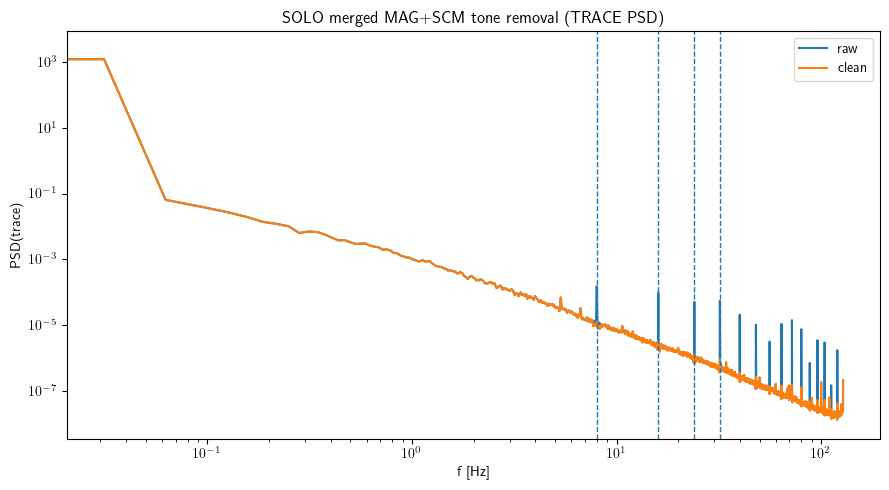

In [27]:
#!/usr/bin/env python
import sys
import time
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

# ---------------------------------------------------------------------
# PATH SETUP
# ---------------------------------------------------------------------
HERE = root_dir

ROOT = root_dir
for p in [HERE.parent] + list(HERE.parents):
    if (p / "functions" / "path_setup.py").exists():
        ROOT = p
        break
if ROOT is None:
    raise RuntimeError(
        "Could not locate repo root containing functions/path_setup.py. "
        "Set ROOT manually to your MHDTurbPy repo root."
    )

# Common MHDTurbPy layout: code lives under ROOT/functions/...
sys.path.insert(0, str(ROOT / "functions"))
sys.path.insert(0, str(ROOT / "functions" / "downloading_helpers"))

import SOLO  # noqa: E402

root_dir = ROOT

# ---------------------------------------------------------------------
# USER INPUT
# ---------------------------------------------------------------------
T0 = "2022-03-01 00:00:00"
T1 = "2022-03-01 02:00:00"

FS = 256.0
FRAME_RTN = True  # True->RTN merged product; False->SRF merged product

# ---------------------------------------------------------------------
# HELPERS
# ---------------------------------------------------------------------
def regularize_to_native_grid(
    df: pd.DataFrame,
    cols,
    fs_hz: float,
    *,
    fill_small_gaps_s: float = 0.05,
) -> pd.DataFrame:
    B = df[cols].astype(float).copy()
    B = B[~B.index.duplicated(keep="first")]
    if len(B) < 2:
        return B

    t_ns = B.index.view("int64")
    dt_ns = int(round(1e9 / float(fs_hz)))
    t0_ns = int(t_ns[0])
    t1_ns = int(t_ns[-1])

    n_grid = int(round((t1_ns - t0_ns) / dt_ns)) + 1
    grid_ns = t0_ns + np.arange(n_grid, dtype=np.int64) * dt_ns
    grid_idx = pd.to_datetime(grid_ns)

    offs_ns = t_ns - t0_ns
    k = np.rint(offs_ns.astype(np.float64) / float(dt_ns)).astype(np.int64)
    k = np.clip(k, 0, n_grid - 1)

    X = np.full((n_grid, len(cols)), np.nan, float)
    vals = B.to_numpy(dtype=float, copy=False)

    # Vectorized scatter (last sample wins if duplicates exist)
    X[k, :] = vals

    out = pd.DataFrame(X, index=grid_idx, columns=cols)
    max_fill = int(max(0, round(fill_small_gaps_s * float(fs_hz))))
    if max_fill > 0:
        out = out.interpolate(method="time", limit=max_fill, limit_area="inside")
    return out


def welch_psd_trace(x: np.ndarray, fs_hz: float):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size < 16:
        return np.array([]), np.array([])
    nper = int(min(8192, x.size))
    f, P = signal.welch(x, fs=fs_hz, nperseg=nper, detrend=False)
    return f, P


def tone_over_baseline(f, P, f0_hz: float, bw_hz: float = 0.20):
    if f.size == 0:
        return np.nan
    m = (f >= f0_hz - bw_hz) & (f <= f0_hz + bw_hz)
    if not m.any():
        return np.nan
    tone = np.median(P[m])

    left = (f >= f0_hz - 3 * bw_hz) & (f <= f0_hz - 2 * bw_hz)
    right = (f >= f0_hz + 2 * bw_hz) & (f <= f0_hz + 3 * bw_hz)
    bases = []
    if left.any():
        bases.append(np.median(P[left]))
    if right.any():
        bases.append(np.median(P[right]))
    base = np.median(bases) if bases else np.nan

    if not np.isfinite(base) or base <= 0:
        return np.nan
    return float(tone / base)


# ---------------------------------------------------------------------
# SETTINGS (download once, clean explicitly)
# ---------------------------------------------------------------------
base_settings = SOLO.init_solo_settings(
    {
        "Data_path": Path(root_dir).joinpath("data"),
        "save_destination": Path(root_dir).joinpath("examples", "noise_removal"),
    }
)
Path(base_settings["Data_path"]).mkdir(parents=True, exist_ok=True)
Path(base_settings["save_destination"]).mkdir(parents=True, exist_ok=True)

base_settings["SOLO_use_merged_MAG"] = True
base_settings["SOLO_merged_fs"] = float(FS)
base_settings["in_rtn"] = 1 if FRAME_RTN else 0

# Force NO cleaning on download (we will clean explicitly below)
settings_dl = copy.deepcopy(base_settings)
settings_dl["Mag_SCM"]["noise_flag"] = False

# Cleaner settings
settings_clean = copy.deepcopy(base_settings)
settings_clean["Mag_SCM"]["noise_flag"] = True

# Optional speed knobs (used only if your SOLO.py implementation reads them)
settings_clean["SOLO_noise_n_jobs"] = 4
settings_clean["SOLO_noise_joblib_prefer"] = "threads"
settings_clean["SOLO_noise_min_run_s"] = 8.0
settings_clean["SOLO_noise_fill_small_gaps_s"] = 0.20
settings_clean["SOLO_noise_split_gap_s"] = 2.0

# ---------------------------------------------------------------------
# LOAD ONCE
# ---------------------------------------------------------------------
t0 = time.perf_counter()
df_raw, src = SOLO.download_MAG_SOLO(T0, T1, settings_dl, varnames=["B_RTN" if FRAME_RTN else "B_SRF"])
t1 = time.perf_counter()
print(f"Download time: {t1 - t0:.2f} s | src={src}")

if df_raw is None or len(df_raw) == 0:
    raise RuntimeError("df_raw empty: merged product not loaded (check SOAR access / product string).")

print("MAG_source:", df_raw.attrs.get("MAG_source"))
print("SCM_merged_loaded:", df_raw.attrs.get("SCM_merged_loaded"))

# Hard fail if you fell back to SPEDAS (then merged cleaner is irrelevant)
if not bool(df_raw.attrs.get("SCM_merged_loaded", False)):
    raise RuntimeError("Merged SCM not loaded (fallback path). Fix SOAR merged loading first.")

# ---------------------------------------------------------------------
# CLEAN EXPLICITLY (so timing is only the cleaner)
# ---------------------------------------------------------------------
noise_flag, noise_cfg = SOLO.resolve_mag_noise_settings(settings_clean)
print("Noise flag resolved:", noise_flag)

df_clean = df_raw.copy()
if noise_flag:
    t0c = time.perf_counter()
    df_clean = SOLO._clean_soar_merged_scm_before_resample(
        merged_df=df_clean,
        settings=settings_clean,
        noise_cfg=noise_cfg,
    )
    t1c = time.perf_counter()
    print(f"Clean time: {t1c - t0c:.2f} s")
else:
    print("Noise flag False -> no cleaning performed.")

print("WHEEL_NOISE_REMOVED:", df_clean.attrs.get("WHEEL_NOISE_REMOVED"))
dbg = df_clean.attrs.get("WHEEL_NOISE_DEBUG") or {}
print("WHEEL_NOISE_DEBUG keys:", sorted(dbg.keys()))

cols = ["Br", "Bt", "Bn"] if all(c in df_raw.columns for c in ["Br", "Bt", "Bn"]) else ["Bx", "By", "Bz"]

# ---------------------------------------------------------------------
# PSD DEMO on a regularized native grid
# ---------------------------------------------------------------------
gpre = regularize_to_native_grid(df_raw, cols, FS)
gpost = regularize_to_native_grid(df_clean, cols, FS)

finite = np.all(np.isfinite(gpre.to_numpy()), axis=1) & np.all(np.isfinite(gpost.to_numpy()), axis=1)
d = np.diff(finite.astype(np.int8))
starts = list(np.where(d == 1)[0] + 1)
ends = list(np.where(d == -1)[0] + 1)
if finite.size and finite[0]:
    starts = [0] + starts
if finite.size and finite[-1]:
    ends = ends + [finite.size]
runs = [(s, e) for s, e in zip(starts, ends) if (e - s) >= int(60 * FS)]
if not runs:
    raise RuntimeError("No >=60s finite run found after regularization; try a different interval.")

s0, e0 = runs[0]

xpre = gpre.iloc[s0:e0].to_numpy()
xpost = gpost.iloc[s0:e0].to_numpy()
tr_pre = np.linalg.norm(xpre, axis=1)
tr_post = np.linalg.norm(xpost, axis=1)

f0, P0 = welch_psd_trace(tr_pre, FS)
f1, P1 = welch_psd_trace(tr_post, FS)

tones = [8.0, 16.0, 24.0, 32.0]
if not FRAME_RTN:
    tones.append(1.33)

print("\nTone-over-baseline (TRACE):")
for f0_hz in tones:
    r0 = tone_over_baseline(f0, P0, f0_hz)
    r1 = tone_over_baseline(f1, P1, f0_hz)
    print(f"  f0={f0_hz:5.2f} Hz | pre={r0:10.3g} | post={r1:10.3g}  (target ~1)")

# ---------------------------------------------------------------------
# PLOT
# ---------------------------------------------------------------------
plt.figure(figsize=(9, 5))
plt.loglog(f0, P0, label="raw")
plt.loglog(f1, P1, label="clean")
for f0_hz in tones:
    plt.axvline(f0_hz, linestyle="--", linewidth=1)
plt.xlabel("f [Hz]")
plt.ylabel("PSD(trace)")
plt.title("SOLO merged MAG+SCM tone removal (TRACE PSD)")
plt.legend()
plt.tight_layout()
plt.show()


In [33]:
B

,Br,Bt,Bn
datetime,,,
2024-10-01 01:00:10.002,60.044975,-39.781952,11.739243
2024-10-01 01:00:10.005,60.050720,-39.785976,11.747190
2024-10-01 01:00:10.008,60.064831,-39.779591,11.757957
2024-10-01 01:00:10.011,60.074059,-39.768471,11.767996
2024-10-01 01:00:10.014,60.072144,-39.774345,11.773220
...,...,...,...
2024-10-01 02:59:46.986,50.501114,3.360058,1.927261
2024-10-01 02:59:46.989,50.491405,3.363672,1.941741
2024-10-01 02:59:46.992,50.498081,3.369057,1.946221


In [29]:
df_clean

,Br,Bt,Bn
datetime,,,
2022-03-01 00:01:44.059939840,0.306095,-5.236886,9.516607
2022-03-01 00:01:44.063846144,0.314038,-5.246368,9.500319
2022-03-01 00:01:44.067752320,0.315053,-5.242900,9.508227
2022-03-01 00:01:44.071658624,0.313273,-5.241935,9.507504
2022-03-01 00:01:44.075564800,0.312380,-5.235065,9.513293
...,...,...,...
2022-03-01 01:59:52.380194190,2.830093,-2.703891,-7.170239
2022-03-01 01:59:52.384100440,2.849096,-2.696142,-7.160136
2022-03-01 01:59:52.388006690,2.863243,-2.698579,-7.156083


In [28]:
import cdflib
from sunpy.net import Fido
import sunpy.net.attrs as a
import sunpy_soar
import pandas as pd

t0, t1 = pd.to_datetime("2022-03-01 00:00:00"), pd.to_datetime("2022-03-01 02:00:00")
product = "multi-mag-rpw-scm-merged-rtn-256"

qr = Fido.search(a.Time(t0, t1), a.soar.Product(product))
files = Fido.fetch(qr)
cdf = cdflib.CDF(str(files[0]))
info = cdf.cdf_info()
print(sorted(info.zVariables))


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

['B_RTN', 'CARTESIAN_REPRESENTATION', 'Epoch', 'MAG_LABEL_RTN', 'MERGED_BITMASK', 'MERGED_LABEL', 'QUALITY_BITMASK', 'QUALITY_BITMASK_MAG', 'QUALITY_BITMASK_SCM', 'QUALITY_FLAG', 'SAMPLING_RATE']
